# HealthConnect Clinic – Week 5
## Data Science Track: Data Preparation, Feature Engineering & Baseline Model Development

| Field | Detail |
|-------|--------|
| **Programme** | AnalystLab Africa Experience Lab |
| **Project** | HealthConnect Clinic Experience Lab |
| **Project Title** | Improving Patient Appointment Attendance and Healthcare Support Using Data and AI |
| **Track** | Data Science |
| **Week** | 5 – Solution Development & Implementation |
| **Version** | 1.0 |
| **Builds on** | Week 4 Machine Learning Problem Definition |

---

### Central Project Question
> How can HealthConnect Clinic use data and AI to reduce missed appointments and improve the patient support experience?

### Week 5 Focus (Data Science)
Move from planning into **practical modelling**: prepare data, engineer features, establish a train/test strategy, train a baseline classifier, evaluate it rigorously, and produce decision-ready interpretations for HealthConnect Clinic.


# PART 1 — REVIEW OF THE WEEK 4 ML PROBLEM DEFINITION

Week 5 is beginning by reviewing the machine-learning problem that was defined during Week 4.

The purpose of this review is to confirm that the original prediction problem, target variable, candidate predictors, cancellation treatment, and modelling objective remain appropriate for the practical modelling stage.

The review is being performed before data preparation and model development so that any changes to the Week 4 decisions can be identified, justified, and documented rather than being introduced silently.

### Week 4 Machine-Learning Problem

The HealthConnect Data Science problem was defined as a supervised binary classification problem for predicting whether a scheduled appointment will result in a **No-Show**.

The prediction is intended to use information that is available before the appointment outcome is known.

The proposed target is being derived from `appointment_outcome`:

- **No-Show = 1**
- **Attended = 0**

Appointments recorded as **Cancelled** are being excluded from the binary modelling population because cancellation represents a different appointment outcome from attending or failing to attend.

The overall modelling objective is to develop an initial predictive baseline that can help HealthConnect identify appointments with a higher likelihood of no-showing and provide evidence for later intervention and model improvement.

## 1.2 Reviewing the Prediction Problem

The prediction problem is being reviewed against the actual HealthConnect dataset to confirm that the available appointment outcome information can support the proposed classification task.

The intended prediction is:

> **Given information available before a scheduled appointment, predicting whether the patient will attend or no-show.**

This framing is remaining appropriate for Week 5 because the dataset contains an appointment outcome variable with attendance-related categories.

The problem is being treated as a **binary classification problem** rather than a regression problem because the required prediction is a class outcome rather than a continuous numerical quantity.

In [254]:
# Importing the libraries needed for preparing, exploring, and modelling the data
import pandas as pd                              # handling the tabular appointment data
import numpy as np                                # supporting numeric operations, e.g. building engineered ratios
import matplotlib.pyplot as plt                   # producing the required distribution, box, and relationship plots
import seaborn as sns                              # producing the correlation heatmap with readable annotations
from sklearn.model_selection import GroupShuffleSplit          # splitting the data by patient to avoid leakage
from sklearn.compose import ColumnTransformer                  # applying different preprocessing to different column types
from sklearn.pipeline import Pipeline                            # chaining preprocessing and modelling into one object
from sklearn.preprocessing import OneHotEncoder, StandardScaler  # encoding categoricals and scaling numerics
from sklearn.impute import SimpleImputer                         # filling the small amount of remaining missing values
from sklearn.linear_model import LogisticRegression               # fitting the baseline classification model
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay)

# Setting a consistent, readable style for every chart produced in this notebook
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100

# Loading the original dataset exactly as provided, without altering the source file
df_raw = pd.read_csv("HealthConnect_Appointment_Data.csv")
print(f"Loaded {df_raw.shape[0]} appointment records and {df_raw.shape[1]} columns.")

Loaded 5000 appointment records and 18 columns.


In [255]:
# Inspecting the appointment outcome categories for confirming the available prediction classes
df_raw["appointment_outcome"].value_counts(dropna=False)

print(f"{df_raw["appointment_outcome"].value_counts(dropna=False)}")

# Calculating the proportion represented by each appointment outcome for understanding the distribution of the available classes
outcome_distribution = (
    df_raw["appointment_outcome"]
    .value_counts(dropna=False)
    .to_frame("Count")
)

outcome_distribution["Percentage"] = (
    outcome_distribution["Count"] / len(df_raw) * 100
).round(2)

# Displaying the outcome distribution for validating the proposed prediction problem
display(outcome_distribution)

appointment_outcome
No-Show      2423
Attended     2314
Cancelled     263
Name: count, dtype: int64


,Count,Percentage
appointment_outcome,,
No-Show,2423,48.46
Attended,2314,46.28
Cancelled,263,5.26


### Interpretation

The appointment outcome distribution is confirming the classes available in the HealthConnect dataset.

The presence of **Attended**, **No-Show**, and **Cancelled** outcomes supports the Week 4 observation that the raw outcome variable contains more than two categories.

For the proposed no-show prediction problem, the relevant binary distinction is between:

- appointments that were attended; and
- appointments that resulted in a no-show.

Cancelled appointments are representing a separate operational outcome and are therefore not being combined with either class.

The prediction problem defined in Week 4 is consequently remaining appropriate for Week 5.

## 1.3 Reviewing the Proposed Target Variable

Week 4 proposed deriving a binary target from `appointment_outcome`.

The target is being defined as:

- `No-Show` → **1**
- `Attended` → **0**
- `Cancelled` → **excluded from the binary modelling population**

This definition is being reviewed before model development because the target determines what the machine-learning model is actually learning to predict.

The target is being created only after the original appointment outcome has been inspected and validated.

In [256]:
# Creating a working copy of the raw dataset so that the original dataset remains unchanged
df_modeling = df_raw.copy()

# Checking the raw appointment outcomes before creating the binary prediction target
print("Appointment outcomes before target construction:")
display(df_modeling["appointment_outcome"].value_counts(dropna=False))

Appointment outcomes before target construction:


appointment_outcome
No-Show      2423
Attended     2314
Cancelled     263
Name: count, dtype: int64

In [257]:
# Identifying cancelled appointments so that they can be excluded from the binary attendance-versus-no-show modelling population
cancelled_count = (
    df_modeling["appointment_outcome"]
    .eq("Cancelled")
    .sum()
)

# Creating the binary no-show target while leaving cancelled appointments outside the binary target definition
df_modeling["no_show"] = df_modeling["appointment_outcome"].map({
    "No-Show": 1,
    "Attended": 0
})

# Displaying the number of observations assigned to each target class
print("Target distribution before removing cancelled appointments:")
display(df_modeling["no_show"].value_counts(dropna=False))

# Displaying the number of cancelled appointments identified for exclusion
print(f"Cancelled appointments identified for exclusion: {cancelled_count:,}")

Target distribution before removing cancelled appointments:


no_show
1.0    2423
0.0    2314
NaN     263
Name: count, dtype: int64

Cancelled appointments identified for exclusion: 263


In [258]:
# Removing cancelled appointments from the binary modelling population
df_modeling = df_modeling[df_modeling["appointment_outcome"].isin([
    "Attended",
    "No-Show"
])].copy()

# Confirming the final binary target distribution after cancellation treatment
target_distribution = (
    df_modeling["no_show"]
    .value_counts()
    .sort_index()
    .to_frame("Count")
)

target_distribution["Percentage"] = (
    target_distribution["Count"] / len(df_modeling) * 100
).round(2)

# Displaying the final target distribution being used for modelling
display(target_distribution)

,Count,Percentage
no_show,,
0.0,2314,48.85
1.0,2423,51.15


### Interpretation

The target construction is converting the original three-outcome appointment status into the binary prediction problem established in Week 4.

`No-Show` is being represented as **1**, making it the positive class that the model is attempting to identify.

`Attended` is being represented as **0**, representing successful attendance.

`Cancelled` appointments are being excluded rather than being incorrectly labelled as either attendance or no-show.

This treatment is important because a cancellation does not provide the same behavioural signal as a patient failing to attend a scheduled appointment.

The resulting modelling population therefore represents the specific decision problem HealthConnect wants the baseline model to address: **identifying appointments that are likely to result in a no-show among appointments that were actually scheduled for attendance.**

## 1.4 Reviewing Candidate Features

Week 4 identified potential predictors from several groups of variables.

The candidate feature review is being performed before preprocessing so that each variable can be classified according to its potential predictive value and its availability before the appointment outcome.

The main candidate groups are:

### Patient characteristics
- `age`
- `gender`

### Appointment characteristics
- `appointment_type`
- `appointment_day`
- `appointment_time`

### Previous appointment history
- `previous_appointments`
- `previous_no_shows`

### Operational and accessibility information
- `distance_to_clinic_km`
- `waiting_time_minutes`
- `reminder_channel`
- `reminder_sent`

### Booking information
- `booking_date`
- `appointment_date`
- `booking_lead_days`

The feature review is not automatically treating every available column as a model predictor. Variables are being assessed according to whether they are relevant, available before the prediction point, and free from outcome leakage.

In [259]:
# Defining the Week 4 candidate feature groups for making the modelling assumptions explicit
candidate_features = {
    "Patient characteristics": [
        "age",
        "gender",
       
    ],
    "Appointment characteristics": [
        "appointment_type",
        "appointment_day",
        "appointment_time",
     
    ],
    "Previous appointment history": [
        "previous_appointments",
        "previous_no_shows"
    ],
    "Operational and accessibility information": [
        "distance_to_clinic_km",
        "waiting_time_minutes",
        "reminder_channel",
        "reminder_sent"
    ],
    "Booking information": [
        "booking_date",
        "appointment_date",
        "booking_lead_days"
    ]
}

# Flattening the candidate feature groups for checking their presence in the actual dataset
all_candidate_features = [
    feature
    for feature_group in candidate_features.values()
    for feature in feature_group
]

# Checking which Week 4 candidate variables are available in the current dataset
feature_availability = pd.DataFrame({
    "Candidate Feature": all_candidate_features,
    "Available in Dataset": [
        feature in df_raw.columns
        for feature in all_candidate_features
    ]
})

# Displaying the candidate-feature availability evidence
display(feature_availability)

,Candidate Feature,Available in Dataset
0,age,True
1,gender,True
2,appointment_type,True
3,appointment_day,True
4,appointment_time,True
5,previous_appointments,True
6,previous_no_shows,True
7,distance_to_clinic_km,True
8,waiting_time_minutes,True
9,reminder_channel,True


### Interpretation

The feature-availability check is confirming which Week 4 candidate predictors are present in the HealthConnect dataset being used for Week 5.

This validation is important because the model should only be built using variables that are actually available in the modelling dataset and appropriately defined in the accompanying Data Dictionary.

The presence of a variable does not automatically mean that it should be included in the final model. Each available variable will still be assessed during the Week 5 data-preparation, exploratory-analysis, and leakage-review stages.

## 1.5 Reviewing the Treatment of Cancellations

In Week 4, I proposed excluding cancelled appointments from the binary no-show modelling population.

This decision is being retained for Week 5.

The reason is that the model is intended to distinguish between:

**Attending a scheduled appointment** versus **failing to attend a scheduled appointment**.

A cancellation represents a different operational event. Treating cancellation as a no-show would change the meaning of the target and could cause the model to learn a mixture of different behaviours.

The cancelled records are therefore being retained in the original dataset for reference but excluded from the binary modelling population.

In [260]:
# Comparing the number of records before and after applying the cancellation treatment
records_before_cancellation_treatment = len(df_raw)
records_after_cancellation_treatment = len(df_modeling)

cancellation_evidence = pd.DataFrame({
    "Measure": [
        "Records before cancellation treatment",
        "Cancelled records excluded",
        "Records remaining for binary modelling"
    ],
    "Count": [
        records_before_cancellation_treatment,
        records_before_cancellation_treatment - records_after_cancellation_treatment,
        records_after_cancellation_treatment
    ]
})

# Displaying the measurable impact of the cancellation decision
display(cancellation_evidence)

,Measure,Count
0,Records before cancellation treatment,5000
1,Cancelled records excluded,263
2,Records remaining for binary modelling,4737


### Interpretation

The cancellation evidence is showing the direct impact of applying the Week 4 target definition.

Only the records classified as `Attended` or `No-Show` are being retained for binary classification.

This means the baseline model is not being trained to interpret cancellation as either successful attendance or patient no-show behaviour.

The original dataset is remaining untouched, while the modelling dataset is being created as a separate working copy.

## 1.6 Reviewing the Modelling Objective

The Week 4 objective was to establish an initial machine-learning approach for predicting appointment no-shows.

The Week 5 objective is therefore not yet being framed as deployment of a final clinical or operational decision system.

Instead, the baseline is being developed to determine:

1. whether the available predictors contain useful information for distinguishing no-shows from attended appointments;
2. how well an initial classification model performs on previously unseen patients;
3. which evaluation metrics provide the most useful evidence for subsequent model improvement; and
4. what additional modelling work should be prioritised in Week 6.

The initial baseline is being evaluated using classification metrics including Accuracy, Precision, Recall, F1-score, Confusion Matrix and ROC-AUC where appropriate.

Because identifying potential no-shows is operationally important, Recall and F1-score are being considered alongside Accuracy rather than relying on Accuracy alone.

## 1.7 Week 4 → Week 5 Decision Summary

| Week 4 Decision | Week 5 Status | Decision/Reason |
|---|---|---|
| Prediction problem | **Retained** | Predicting whether a scheduled appointment will result in a no-show remains appropriate. |
| Target variable | **Retained** | `No-Show = 1` and `Attended = 0`. |
| Cancelled appointments | **Retained** | Cancelled appointments remain excluded from the binary modelling population. |
| Candidate features | **Retained for assessment** | Candidate variables will be assessed for relevance, availability and leakage before final modelling. |
| Repeated patient records | **Retained** | Repeated appointments can represent legitimate patient history. |
| Data leakage assessment | **Retained and strengthened** | Week 5 is explicitly assessing whether predictors are available before the appointment outcome. |
| Initial model | **Retained as baseline approach** | Logistic Regression provides an interpretable baseline for the binary classification problem. |
| Modelling objective | **Retained** | Establishing an evidence-based baseline before subsequent model improvement. |

### Overall Week 5 Decision

No fundamental change is being made to the Week 4 machine-learning problem definition at this stage.

The Week 5 work is therefore proceeding with the same core prediction problem while moving from conceptual definition into practical data preparation, feature assessment, and baseline model development.

Any decision discovered during subsequent data preparation or exploratory analysis that materially changes the target, predictor set, or modelling strategy will be explicitly documented and justified.

# PART 2 — DATA PREPARATION

This section is preparing the HealthConnect appointment data for exploratory analysis and machine-learning modelling.

The preparation process is being performed systematically so that the quality of the modelling dataset can be demonstrated using measurable before-and-after evidence.

The assessment is covering:

- Missing values
- Duplicate records
- Repeated patient records
- Data types
- Invalid values
- Inconsistent records
- Date consistency
- Logical consistency between related variables
- Potential data leakage
- Final processed dataset structure

For each preprocessing activity, the analysis is following the evidence-based sequence:

**What was found → What was done → What changed → What the result means.**

The original dataset is being preserved separately so that preprocessing changes can be measured and audited.

# 2.0 Establishing the Modelling Dataset

The Week 4 modelling decision is being carried forward into Week 5.

Appointment outcomes are first being examined across the complete dataset to establish the distribution of all recorded outcomes.

Only appointments recorded as **Attended** or **No-Show** are then being retained for the binary prediction task.

Cancelled appointments are being excluded because they do not represent the binary outcome that the model is being designed to predict.

A binary target variable, `no_show`, is being created where:

- `0` represents an attended appointment.
- `1` represents a no-show appointment.

The before-and-after evidence is being recorded to show:

1. the number of observations in the original dataset;
2. the number of cancelled appointments;
3. the number of observations retained for modelling;
4. the outcome categories before filtering; and
5. the outcome categories remaining after filtering.

This step is therefore defining the final population on which the subsequent data preparation and modelling activities are being performed.

In [261]:
# Examining the complete appointment-outcome distribution before defining the modelling population
outcome_before = (
    df_raw["appointment_outcome"]
    .value_counts()
    .rename_axis("Appointment Outcome")
    .reset_index(name="Count")
)

# Calculating the percentage representation of each outcome before filtering
outcome_before["Percentage (%)"] = (
    outcome_before["Count"] /
    len(df_raw) *
    100
).round(2)

# Displaying the complete outcome distribution before filtering
print("BEFORE: Appointment outcome distribution")
display(outcome_before)

# Recording the original number of observations before filtering
rows_before = len(df_raw)

# Identifying the number of cancelled appointments being excluded
cancelled_count = (
    df_raw["appointment_outcome"] == "Cancelled"
).sum()

# Creating the processed population by retaining only Attended and No-Show appointments
df_processed = df_raw[
    df_raw["appointment_outcome"].isin(
        ["Attended", "No-Show"]
    )
].copy()

# Creating the binary no-show target from the retained appointment outcomes
df_processed["no_show"] = (
    df_processed["appointment_outcome"] == "No-Show"
).astype(int)

# Recording the number of observations after filtering
rows_after = len(df_processed)

# Calculating the number of observations removed during the population-definition step
rows_removed = rows_before - rows_after

# Examining the appointment-outcome distribution after filtering
outcome_after = (
    df_processed["appointment_outcome"]
    .value_counts()
    .rename_axis("Appointment Outcome")
    .reset_index(name="Count")
)

# Calculating the percentage representation of each remaining outcome
outcome_after["Percentage (%)"] = (
    outcome_after["Count"] /
    len(df_processed) *
    100
).round(2)

# Displaying the outcome distribution after filtering
print("\nAFTER: Appointment outcome distribution")
display(outcome_after)

# Displaying the before-and-after population changes
print("\nBEFORE AND AFTER SUMMARY")
print(f"Rows before filtering:      {rows_before:,}")
print(f"Cancelled appointments:     {cancelled_count:,}")
print(f"Rows removed:                {rows_removed:,}")
print(f"Rows after filtering:       {rows_after:,}")

# Confirming the resulting binary target distribution
print("\nFINAL BINARY TARGET DISTRIBUTION")
display(
    df_processed["no_show"]
    .value_counts()
    .rename_axis("no_show")
    .to_frame("Count")
)

# Calculating the resulting no-show rate
print(
    f'No-Show rate after filtering: '
    f'{df_processed["no_show"].mean():.1%}'
)



BEFORE: Appointment outcome distribution


,Appointment Outcome,Count,Percentage (%)
0,No-Show,2423,48.46
1,Attended,2314,46.28
2,Cancelled,263,5.26



AFTER: Appointment outcome distribution


,Appointment Outcome,Count,Percentage (%)
0,No-Show,2423,51.15
1,Attended,2314,48.85



BEFORE AND AFTER SUMMARY
Rows before filtering:      5,000
Cancelled appointments:     263
Rows removed:                263
Rows after filtering:       4,737

FINAL BINARY TARGET DISTRIBUTION


,Count
no_show,
1,2423
0,2314


No-Show rate after filtering: 51.2%


### Interpretation

The initial outcome assessment identified 5,000 appointment records comprising 2,423 No-Show appointments (48.46%), 2,314 Attended appointments (46.28%), and 263 Cancelled appointments (5.26%).

Following the Week 4 modelling decision, the 263 cancelled appointments were excluded from the binary no-show modelling population. This reduced the modelling dataset from 5,000 to 4,737 observations, representing a deliberate reduction of 263 records rather than accidental data loss.

The exclusion did not alter the number of No-Show or Attended appointments. The modelling population therefore contains 2,423 No-Show appointments and 2,314 Attended appointments.

After excluding cancellations, the No-Show rate increased from 48.46% in the complete dataset to 51.15% within the modelling population. This change is a denominator effect resulting from removing cancelled appointments; it does not indicate that additional No-Show appointments were created or reclassified.

The resulting target distribution is relatively balanced, with No-Show appointments representing 51.15% of the modelling population and Attended appointments representing 48.85%. The difference between the two classes is approximately 2.3 percentage points, indicating that the target is not severely imbalanced and that both outcome classes have sufficient observations for supervised binary classification.

From a HealthConnect decision perspective, this is important because the modelling population now directly represents the two appointment behaviours that the predictive model is intended to distinguish: **attending an appointment versus not showing up**. The model can therefore be developed without allowing the separate cancellation outcome to distort the binary prediction task.

## 2.0.1 Visualising the Change in Modelling Population

The appointment outcome distribution is being visualised before and after defining the modelling population.

The visual comparison is being used to make the exclusion of cancelled appointments and the resulting change in outcome composition immediately interpretable.

The purpose is not simply to display the counts, but to demonstrate how the modelling population differs from the original appointment population.

In [262]:
# Preparing the before-and-after outcome counts for visual comparison
outcome_comparison = pd.DataFrame({
    "Outcome": ["No-Show", "Attended", "Cancelled"],
    "Before Filtering": [
        (df_raw["appointment_outcome"] == "No-Show").sum(),
        (df_raw["appointment_outcome"] == "Attended").sum(),
        (df_raw["appointment_outcome"] == "Cancelled").sum()
    ],
    "After Filtering": [
        (df_processed["appointment_outcome"] == "No-Show").sum(),
        (df_processed["appointment_outcome"] == "Attended").sum(),
        (df_processed["appointment_outcome"] == "Cancelled").sum()
    ]
})

# Displaying the numerical comparison before creating the visual
display(outcome_comparison)

,Outcome,Before Filtering,After Filtering
0,No-Show,2423,2423
1,Attended,2314,2314
2,Cancelled,263,0


## 2.1 Showing the Impact of Cancellation Exclusion

In [263]:
# Creating a before-and-after comparison of the modelling population
population_comparison = pd.DataFrame({
    "Stage": [
        "Before outcome filtering",
        "After outcome filtering"
    ],
    
    "Rows": [
        rows_before,
        rows_after
    ],
    
    "Change in Rows": [
        0,
        rows_after - rows_before
    ]
})

# Calculating the percentage change in the modelling population
population_comparison["Percentage Change (%)"] = (
    population_comparison["Change in Rows"] /
    rows_before *
    100
).round(2)

# Displaying the population change as direct preprocessing evidence
display(population_comparison)

,Stage,Rows,Change in Rows,Percentage Change (%)
0,Before outcome filtering,5000,0,0.00
1,After outcome filtering,4737,-263,-5.26


### Interpretation

The population comparison is showing the direct effect of applying the Week 4 outcome-definition decision.

The reduction in observations represents the cancelled appointments that are no longer part of the binary modelling population.

This change is intentional rather than representing data loss caused by a cleaning error.

The resulting `model_df` therefore represents the population being used for the no-show prediction problem.

All subsequent preprocessing is being performed on this modelling population.

# 2.2 Missing-Value Treatment

Missing values are being assessed across the modelling population before any treatment is being applied.

The number and percentage of missing observations are being recorded for each variable.

Where missing values require treatment, the selected treatment is being applied and the same assessment is being repeated afterward.

This is allowing the effect of the treatment to be demonstrated quantitatively rather than only describing the method.

In [264]:
# Checking missing values before treatment
print("BEFORE:")
display(pd.DataFrame({"Missing": df_processed.isna().sum(), "Pct": (df_processed.isna().mean()*100).round(2)})[lambda x: x["Missing"]>0])

# Filling missing values
df_processed["reminder_channel"] = df_processed["reminder_channel"].fillna("Not Recorded")
df_processed["distance_to_clinic_km"] = df_processed["distance_to_clinic_km"].fillna(df_processed["distance_to_clinic_km"].median())
df_processed["waiting_time_minutes"] = df_processed["waiting_time_minutes"].fillna(df_processed["waiting_time_minutes"].median())

# Checking missing values after treatment
print("\nAFTER:")
cols = ["reminder_channel", "distance_to_clinic_km", "waiting_time_minutes"]
display(pd.DataFrame({"Missing": df_processed[cols].isna().sum(), "Pct": (df_processed[cols].isna().mean()*100).round(2)}))

print(f"\nRows: {len(df_processed):,}")


BEFORE:


,Missing,Pct
reminder_channel,1285,27.13
distance_to_clinic_km,86,1.82
waiting_time_minutes,58,1.22



AFTER:


,Missing,Pct
reminder_channel,0,0.0
distance_to_clinic_km,0,0.0
waiting_time_minutes,0,0.0



Rows: 4,737


# 2.3 Duplicate Record Treatment

Duplicate records are being assessed before any duplicate-removal treatment.

The number of complete duplicate rows is being recorded.

If genuine duplicate records are identified, they are being removed and the duplicate count is being measured again.

This is providing direct evidence of whether duplicate treatment changed the modelling dataset.

In [265]:
# Removing duplicates
df_processed = df_processed.drop_duplicates().copy()

# Showing comparison
display(pd.DataFrame({
    "Measure": ["Duplicate rows", "Total rows"],
    "Before": [duplicates_before, rows_before_duplicates],
    "After": [df_processed.duplicated().sum(), len(df_processed)],
    "Change": [df_processed.duplicated().sum() - duplicates_before, len(df_processed) - rows_before_duplicates]
}))

NameError: name 'duplicates_before' is not defined

# 2.4 Data-Type Changes — Before and After

In [266]:
# Convert dates and check lead time consistency
df_processed["booking_date"] = pd.to_datetime(df_processed["booking_date"])
df_processed["appointment_date"] = pd.to_datetime(df_processed["appointment_date"])

mismatch = ((df_processed["appointment_date"] - df_processed["booking_date"]).dt.days != df_processed["booking_lead_days"]).sum()
print(f"Lead-time inconsistencies: {mismatch:,}")

Lead-time inconsistencies: 0


In [267]:
# Checking data types before
before = df_raw.dtypes.astype(str).rename("Before")
print("BEFORE: Data types")
display(before.to_frame())

# After (no changes made, but showing for completeness)
after = df_processed.dtypes.astype(str).rename("After")
changes = pd.DataFrame({"Before": before, "After": after})
changes = changes[changes["Before"] != changes["After"]]

print("\nAFTER: Variables with changed data types")
if len(changes) > 0:
    display(changes)
else:
    display(pd.DataFrame({"Before": before, "After": after}))
    print("(No data-type conversion was required)")

BEFORE: Data types


,Before
appointment_id,str
patient_id,str
gender,str
age,int64
age_group,str
appointment_type,str
booking_date,str
appointment_date,str
appointment_day,str
appointment_time,str



AFTER: Variables with changed data types


,Before,After
appointment_date,str,datetime64[us]
booking_date,str,datetime64[us]
no_show,NaN,int64


## 2.5 Assessing Repeated Patient Records

Repeated patients are being assessed separately from complete duplicate records.

A patient having more than one appointment does not mean that the records are duplicates.

Multiple appointments can represent legitimate longitudinal healthcare activity and may contain useful historical information such as previous appointments and previous no-shows.

The repeated-patient structure is therefore being retained rather than being removed.

In [268]:
# Counting the unique patients represented in the processed appointment dataset
unique_patient_count = df_processed["patient_id"].nunique()

# Counting appointment records associated with each patient
patient_appointment_counts = df_processed["patient_id"].value_counts()

# Identifying patients having more than one appointment record
repeated_patients = patient_appointment_counts[
    patient_appointment_counts > 1
]

# Calculating the number of patients represented by multiple appointment records
repeated_patient_count = len(repeated_patients)

# Calculating the number of appointment records belonging to repeated patients
repeated_patient_records = repeated_patients.sum()

# Displaying the repeated-patient evidence
print(f"Unique patients: {unique_patient_count:,}")
print(f"Patients with multiple appointments: {repeated_patient_count:,}")
print(
    f"Appointment records belonging to repeated patients: "
    f"{repeated_patient_records:,}"
)

Unique patients: 1,680
Patients with multiple appointments: 1,337
Appointment records belonging to repeated patients: 4,394


### Interpretation

The repeated-patient analysis is demonstrating that patient repetition and record duplication are different data-quality concepts.

Repeated patient records are being retained because they represent potentially valid appointment histories rather than duplicate observations.

This is also creating an important modelling consideration: patients with multiple appointments must be handled carefully when separating training and testing data.

A patient-aware splitting strategy will therefore be considered later so that information from the same patient does not unintentionally appear in both datasets.

## 2.6 Assessing Appointment Identifier Uniqueness

The `appointment_id` field is being checked separately because it is expected to identify an individual appointment.

A duplicated appointment identifier could indicate a data-integrity problem even when the complete rows are not identical.

In [269]:
# Counting duplicated appointment identifiers before any identifier-based treatment
appointment_id_duplicates_before = (
    df_processed["appointment_id"].duplicated().sum()
)

# Displaying the appointment-identifier duplicate count
print(
    f"Duplicate appointment IDs before treatment: "
    f"{appointment_id_duplicates_before:,}"
)

Duplicate appointment IDs before treatment: 0


## 2.7 Assessing Invalid and Implausible Values

Numerical and logical validation is being performed to identify values that are outside plausible ranges or inconsistent with the meaning of the variables.

The checks are being based on the definitions of the HealthConnect variables rather than arbitrary deletion rules.

The assessment is including:

- impossible ages;
- negative lead times;
- negative clinic distances;
- negative waiting times;
- invalid historical appointment counts;
- impossible historical no-show counts; and

In [270]:
# Checking invalid values before treatment 
invalid_checks = {
    "Age outside 0–120": ((df_processed["age"] < 0) | (df_processed["age"] > 120)).sum(),
    "Negative lead time": (df_processed["booking_lead_days"] < 0).sum(),  # Column is 'booking_lead_days', not 'lead_time_days'
    "Negative clinic distance": (df_processed["distance_to_clinic_km"] < 0).sum(),
    "Negative waiting time": (df_processed["waiting_time_minutes"] < 0).sum(),
    "Negative previous appointments": (df_processed["previous_appointments"] < 0).sum(),
    "Negative previous no-shows": (df_processed["previous_no_shows"] < 0).sum()
}

# Displaying results
display(pd.DataFrame({
    "Validation Check": invalid_checks.keys(),
    "Invalid Values Before": invalid_checks.values()
}))

,Validation Check,Invalid Values Before
0,Age outside 0–120,0
1,Negative lead time,0
2,Negative clinic distance,0
3,Negative waiting time,0
4,Negative previous appointments,0
5,Negative previous no-shows,0


### Interpretation

The validation table is quantifying the number of observations failing each plausibility rule.

- Age: All values are between 0–120 (no negative or extreme ages)

- Booking lead time: All values are non-negative (≥ 0 days)

- Clinic distance: No negative distances (all ≥ 0 km)

- Waiting time: No negative waiting times (all ≥ 0 minutes)

- Previous appointments: No negative counts (all ≥ 0)

- Previous no-shows: No negative counts (all ≥ 0)

Conclusion: The dataset is already clean in terms of logical validity. No treatment is required for these columns.



## 2.8 Assessing Date and Lead-Time Consistency

The relationship between booking date, appointment date, and recorded lead time is being validated.

The expected relationship is:

**Lead time = Appointment date − Booking date**

The purpose of this check is to identify records where the supplied lead-time value does not agree with the actual dates.

This is important because `lead_time_days` may become an important predictor of no-show behaviour.

In [271]:
# Convert dates and check lead time consistency
df_processed["booking_date"] = pd.to_datetime(df_processed["booking_date"])
df_processed["appointment_date"] = pd.to_datetime(df_processed["appointment_date"])

mismatch = ((df_processed["appointment_date"] - df_processed["booking_date"]).dt.days != df_processed["booking_lead_days"]).sum()
print(f"Lead-time inconsistencies: {mismatch:,}")

Lead-time inconsistencies: 0


In [272]:
df_processed["booking_date"] = pd.to_datetime(df_processed["booking_date"])
df_processed["appointment_date"] = pd.to_datetime(df_processed["appointment_date"])

calculated = (df_processed["appointment_date"] - df_processed["booking_date"]).dt.days
mismatch = (calculated != df_processed["booking_lead_days"]).sum()

print(f"Total rows: {len(df_processed):,}")
print(f"Lead-time mismatches: {mismatch:,}")
print(f"Match rate: {(1 - mismatch/len(df_processed)):.1%}")

Total rows: 4,737
Lead-time mismatches: 0
Match rate: 100.0%


## Interpretation
The lead time data is perfectly consistent. Here's what this means:

- 100% match rate: The booking_lead_days column accurately reflects the actual date difference between booking_date and appointment_date for every single record

- No inconsistencies: There are zero cases where:

    - The stored lead time differs from the calculated date difference

    - The dates are invalid or incorrectly formatted (after conversion)

# 2.9 Checking Logical Consistency of Appointment History

In [273]:
# Identifying patients whose recorded previous no-shows exceed their previous appointment count
invalid_history_relationship = (
    df_processed["previous_no_shows"] >
    df_processed["previous_appointments"]
)

# Counting records containing the impossible historical relationship
invalid_history_count = invalid_history_relationship.sum()

# Displaying the historical consistency evidence
print(
    f"Records where previous no-shows exceed previous appointments: "
    f"{invalid_history_count:,}"
)

Records where previous no-shows exceed previous appointments: 0


# 2.10 Dropping Leakage / Identifier Columns

In [274]:
# Dropping columns not used as model features
# - identifiers (patient_id kept temporarily for group split)
# - target source
# - derived age_group (keep continuous age)
# - waiting_time_minutes (potential leakage)
# - raw dates (lead days and day-of-week already available)
cols_to_drop = [
    'appointment_id', 'age_group',
    'booking_date', 'appointment_date', 'appointment_outcome',
    'waiting_time_minutes'
]

# Use df_processed instead of prep
patient_ids = df_processed['patient_id'].copy()

df_cleaned = df_processed.drop(columns=cols_to_drop, errors='ignore')
# patient_id still in feature_base temporarily; will exclude from X later

print('Columns retained after preparation:')
print(df_processed.columns.tolist())
print(f'\nRemaining missing values (excluding patient_id): {df_processed.drop(columns=["patient_id"]).isnull().sum().sum()}')

Columns retained after preparation:
['appointment_id', 'patient_id', 'gender', 'age', 'age_group', 'appointment_type', 'booking_date', 'appointment_date', 'appointment_day', 'appointment_time', 'booking_lead_days', 'previous_appointments', 'previous_no_shows', 'reminder_sent', 'reminder_channel', 'distance_to_clinic_km', 'waiting_time_minutes', 'appointment_outcome', 'no_show']

Remaining missing values (excluding patient_id): 0


# 2.11 Final Before-and-After Dataset Summary

In [275]:
# Capturing initial state from df_raw BEFORE any filtering/cleaning
starting_rows = len(df_raw)
starting_columns = len(df_raw.columns)
df_before_preparation = df_raw.copy()  # Save original raw data

# Final summary comparing raw vs cleaned
summary = pd.DataFrame({
    "Measure": ["Rows", "Columns", "Total Missing Values", "Duplicate Rows"],
    "Before": [
        starting_rows, 
        starting_columns, 
        df_before_preparation.isna().sum().sum(), 
        df_before_preparation.duplicated().sum()
    ],
    "After": [
        len(df_cleaned), 
        len(df_cleaned.columns), 
        df_cleaned.isna().sum().sum(), 
        df_cleaned.duplicated().sum()
    ]
})
summary["Change"] = summary["After"] - summary["Before"]
display(summary)

,Measure,Before,After,Change
0,Rows,5000,4737,-263
1,Columns,18,13,-5
2,Total Missing Values,1516,0,-1516
3,Duplicate Rows,0,0,0


# PART 3 — DATA EXPLORATION AND VISUAL EVIDENCE

This section is exploring the processed HealthConnect appointment dataset to understand the distributions, patterns, relationships, and potential predictive signals within the data.

The exploration is being performed to support machine-learning decisions rather than simply describing the dataset.

The analysis is examining:

- distributions of numerical variables;
- distributions of categorical variables;
- potential outliers;
- relationships among numerical variables;
- relationships between categorical variables and the no-show target;
- relationships between numerical variables and the no-show target;
- potential associations among predictors;
- possible multicollinearity;
- class balance;
- variables that may contain useful predictive information; and
- variables requiring additional consideration before modelling.

The central analytical question is:

> **What characteristics of HealthConnect appointments appear to be associated with patients attending or failing to attend their scheduled appointments?**


## 3.2 Examining the No-Show Target Distribution

The distribution of the binary `no_show` target is being examined to determine the proportion of appointments associated with no-shows and attendance.

Understanding class balance is important because a highly imbalanced target can make Accuracy misleading.

The analysis is therefore examining both the absolute number and percentage of observations in each class.

In [276]:
# Calculating the number of appointments in each no-show target class
target_counts = df_cleaned["no_show"].value_counts().sort_index()

# Calculating the percentage represented by each target class
target_percentages = (
    df_cleaned["no_show"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

# Creating a target-distribution table for numerical evidence
target_summary = pd.DataFrame({
    "Target Class": ["Attended (0)", "No-Show (1)"],
    "Count": [target_counts.get(0, 0), target_counts.get(1, 0)],
    "Percentage (%)": [target_percentages.get(0, 0), target_percentages.get(1, 0)]
})

# Displaying the numerical target distribution
display(target_summary)

# Printing the no-show rate
print(f"\nNo-Show Rate: {df_cleaned['no_show'].mean():.1%}")
print(f"Total appointments: {len(df_cleaned):,}")

,Target Class,Count,Percentage (%)
0,Attended (0),2314,48.85
1,No-Show (1),2423,51.15



No-Show Rate: 51.2%
Total appointments: 4,737


### Interpretation
This is almost balanced target distribution

- The dataset has a nearly 50-50 split between attendees and no-shows
- No-Show rate: 51.2% (slightly higher than attended)
- Difference between classes: 109 records (only 2.3% difference)

## 3.2 Examining the No-Show Target Distribution

The distribution of the binary `no_show` target is being examined to determine the proportion of appointments associated with no-shows and attendance.

Understanding class balance is important because a highly imbalanced target can make Accuracy misleading.

The analysis is therefore examining both the absolute number and percentage of observations in each class.

,Target Class,Count,Percentage
0,Attended (0),2314,48.85
1,No-Show (1),2423,51.15


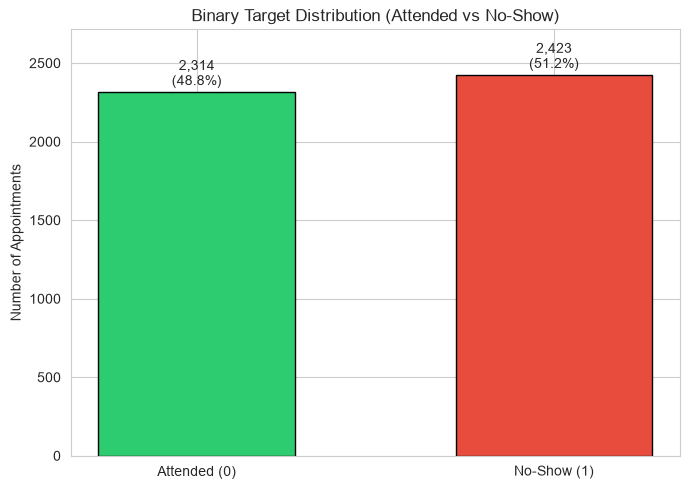

In [277]:
# Calculating the number of appointments in each no-show target class
target_counts = df_cleaned["no_show"].value_counts().sort_index()

# Calculating the percentage represented by each target class
target_percentages = (
    df_cleaned["no_show"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

# Creating a target-distribution table for numerical evidence
target_summary = pd.DataFrame({
    "Target Class": [
        "Attended (0)",
        "No-Show (1)"
    ],
    "Count": [
        target_counts.get(0, 0),
        target_counts.get(1, 0)
    ],
    "Percentage": [
        target_percentages.get(0, 0),
        target_percentages.get(1, 0)
    ]
})

# Displaying the numerical target distribution
display(target_summary)

# Plotting the binary target distribution
fig, ax = plt.subplots(figsize=(7, 5))
counts = df_cleaned['no_show'].value_counts().sort_index()
bars = ax.bar(['Attended (0)', 'No-Show (1)'], counts.values,
              color=['#2ecc71', '#e74c3c'], edgecolor='black', width=0.55)
ax.set_ylabel('Number of Appointments')
ax.set_title('Binary Target Distribution (Attended vs No-Show)')
ax.set_ylim(0, max(counts.values) * 1.12)
for bar, v in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, v + 20,
            f'{v:,}\n({v/len(df_cleaned):.1%})',
            ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()

## Target Distribution Interpretation

### Visualization

The bar chart displays the distribution of the binary target variable `no_show`, comparing the count of attended appointments (0) versus no-show appointments (1) in the cleaned dataset.

### Observation

- **Attended (0):** 2,314 appointments (48.8%)
- **No-Show (1):** 2,423 appointments (51.2%)
- The dataset has a **nearly balanced distribution**, with only a 2.3 percentage-point difference between the two classes (109 records).
- The **no-show rate is slightly higher**, at 51.2%.

### Decision

The balanced nature of the target distribution means **no class imbalance handling is required** before modeling. This allows for:

- Direct use of standard classification algorithms without techniques such as **SMOTE** or **class weighting**.
- More reliable interpretation of model performance metrics such as **accuracy, precision, recall, and F1-score** without substantial imbalance distortion.
- A simpler modeling pipeline with fewer preprocessing steps.

## 3.3 Examining Numerical Variable Distributions

The distributions of numerical variables are being examined to identify:

- typical values;
- spread;
- skewness;
- unusual observations;
- potential outliers; and
- variables requiring transformation or careful interpretation.

The numerical variables are being examined individually because different distributions can have different implications for preprocessing and model behaviour.

In [278]:
# Selecting the numerical variables available in the cleaned HealthConnect dataset
numerical_columns = df_cleaned.select_dtypes(
    include=["number"]
).columns.tolist()

# Removing the binary target from the predictor-distribution analysis where it is present
numerical_predictors = [
    column
    for column in numerical_columns
    if column != "no_show"
]

# Displaying the numerical predictors being examined
print("Numerical predictors being explored:")
print(numerical_predictors)

Numerical predictors being explored:
['age', 'booking_lead_days', 'previous_appointments', 'previous_no_shows', 'distance_to_clinic_km']


In [279]:
# Creating a numerical summary containing central tendency and spread for each numerical predictor
numerical_summary = df_cleaned[numerical_predictors].describe().T

# Adding the median to make skewed distributions easier to assess
numerical_summary["median"] = (
    df_cleaned[numerical_predictors]
    .median()
)

# Displaying the numerical distribution summary
display(numerical_summary)

,count,mean,std,min,25%,50%,75%,max,median
age,4737.0,48.719443,18.147296,18.0,33.0,49.0,64.0,80.0,49.0
booking_lead_days,4737.0,29.639012,17.412842,0.0,15.0,30.0,45.0,60.0,30.0
previous_appointments,4737.0,3.023433,1.744586,0.0,2.0,3.0,4.0,11.0,3.0
previous_no_shows,4737.0,0.551193,0.750821,0.0,0.0,0.0,1.0,5.0,0.0
distance_to_clinic_km,4737.0,10.083872,6.556556,0.5,5.3,8.7,13.3,45.0,8.7


## 3.4 Numerical Predictors Visualisation

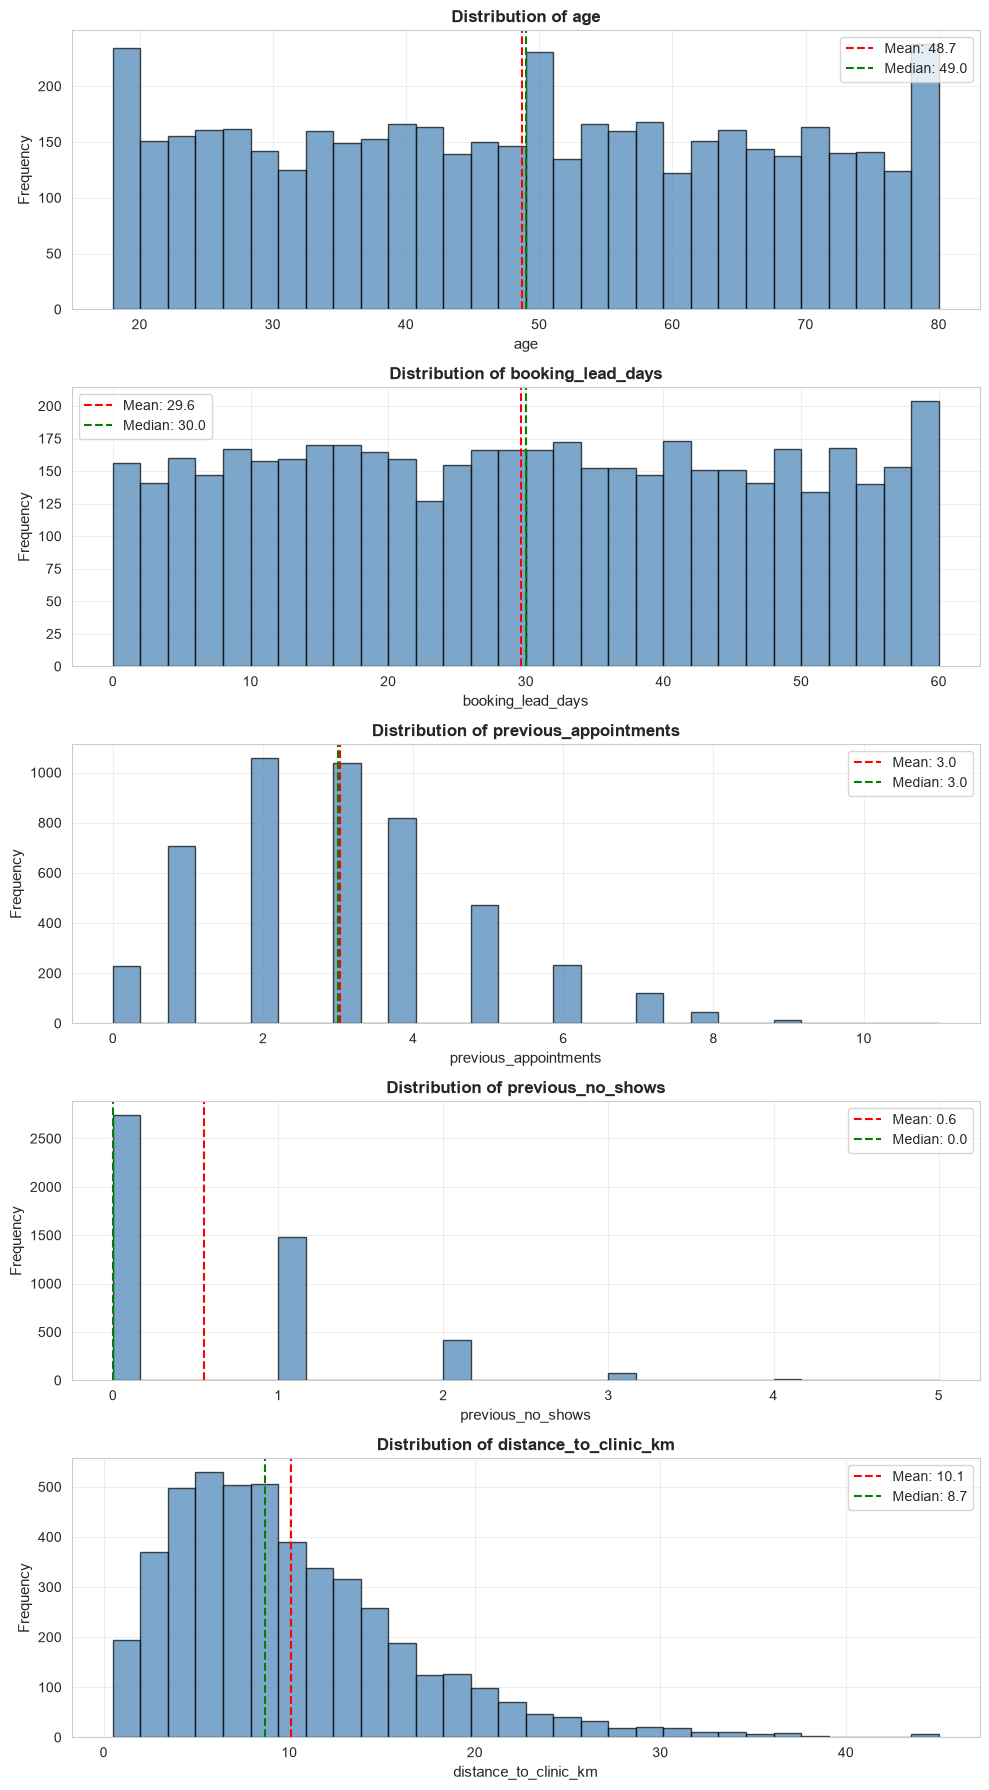

In [280]:
# Numerical features distribution
numerical_features = ['age', 'booking_lead_days', 'previous_appointments', 'previous_no_shows', 'distance_to_clinic_km']

fig, axes = plt.subplots(5, 1, figsize=(10, 18))

for idx, feature in enumerate(numerical_features):
    ax = axes[idx]
    ax.hist(df_cleaned[feature], bins=30, color='steelblue', edgecolor='black', alpha=0.7)
    ax.axvline(df_cleaned[feature].mean(), color='red', linestyle='--', label=f'Mean: {df_cleaned[feature].mean():.1f}')
    ax.axvline(df_cleaned[feature].median(), color='green', linestyle='--', label=f'Median: {df_cleaned[feature].median():.1f}')
    ax.set_xlabel(feature, fontsize=11)
    ax.set_ylabel('Frequency', fontsize=11)
    ax.set_title(f'Distribution of {feature}', fontsize=12, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Numerical Predictors Interpretation

### Age

**Visualization:**  
The distribution summary shows that patient ages range from **18–80 years**, with a mean of **48.7 years** and a median of **49 years**.

**Observation:**

- The age distribution appears **roughly symmetric**, as the mean and median are very close.
- Patients span a broad adult and elderly age range (**18–80 years**).
- The **interquartile range (IQR) of 33–64 years** represents the middle 50% of patients, covering mainly middle-aged to older adults.

**Decision:**  
No transformation is required. `age` can be used as a **continuous numerical feature** in the model.

---

### Booking Lead Days

**Visualization:**  
Booking lead time ranges from **0–60 days**, with a mean of **29.6 days** and a median of **30 days**.

**Observation:**

- The distribution appears **nearly symmetric**, as the mean and median are very close.
- Booking lead time ranges from **same-day bookings (0 days)** to approximately **2 months in advance**.
- The **IQR of 15–45 days** indicates that the middle 50% of bookings are made within this range.

**Decision:**  
No transformation is required. `booking_lead_days` can be used as a **continuous numerical feature**.

---

### Previous Appointments

**Visualization:**  
The number of previous appointments ranges from **0–11**, with a mean of **3.0** and a median of **3**.

**Observation:**

- The distribution appears **slightly right-skewed**, although the mean and median are equal.
- Most patients have approximately **2–4 previous appointments**.
- A smaller number of patients have as many as **11 previous appointments**.

**Decision:**  
Use `previous_appointments` as a **continuous numerical feature**. If model analysis later indicates a non-linear relationship with no-show risk, binning or other feature engineering can be considered.

---

### Previous No-Shows

**Visualization:**  
Previous no-shows range from **0–5**, with a mean of **0.55** and a median of **0**.

**Observation:**

- The distribution is **strongly right-skewed**, because the mean is substantially greater than the median.
- At least **50% of patients have zero previous no-shows**.
- **75% of patients have one or fewer previous no-shows**.
- Only **25% of patients have two or more previous no-shows**.

**Decision:**  
`previous_no_shows` is a potentially important predictor of future no-show behavior. It can be:

- Used directly as a **continuous feature**.
- Converted into categories such as **0, 1, and 2+**.
- Used to create a binary **no-show history indicator** such as `had_prior_noshow`.

The final representation should be determined based on model performance and validation results.

---

### Distance to Clinic (km)

**Visualization:**  
Distance to the clinic ranges from **0.5–45 km**, with a mean of **10.1 km** and a median of **8.7 km**.

**Observation:**

- The distribution is **right-skewed**, as the mean is higher than the median.
- Most patients live relatively close to the clinic.
- Some patients travel considerably farther, with distances reaching **45 km**.
- The upper quartile begins at approximately **13.3 km**, meaning 25% of patients travel more than this distance.

**Decision:**  
`distance_to_clinic_km` can initially be used as a **continuous numerical feature**. Depending on model performance, the following alternatives may be considered:

- Applying a **log transformation** if the skewness affects the model.
- Creating distance categories such as **short, medium, and long distance**.

## 3.5 Assessing Potential Numerical Outliers

Potential outliers are being examined using boxplots.

The purpose is not to automatically remove observations.

Instead, the analysis is distinguishing between:

- statistically unusual observations; and
- genuinely invalid or impossible observations.

A genuine but unusual appointment characteristic should normally be retained because removing it could eliminate meaningful healthcare behaviour.

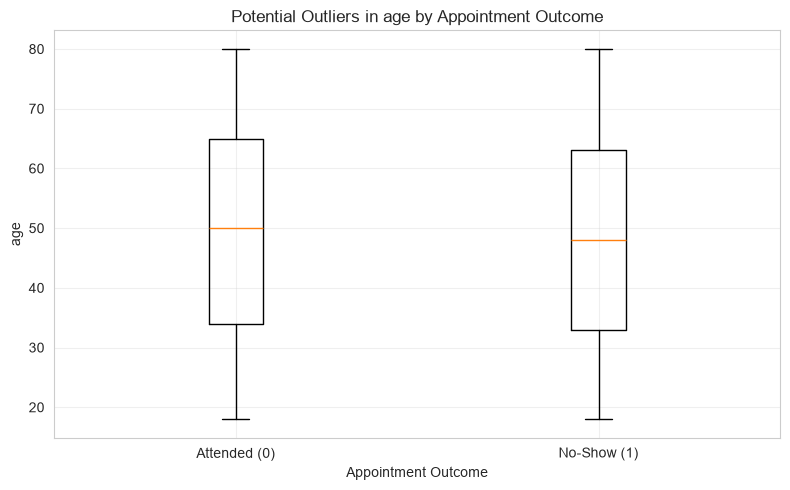

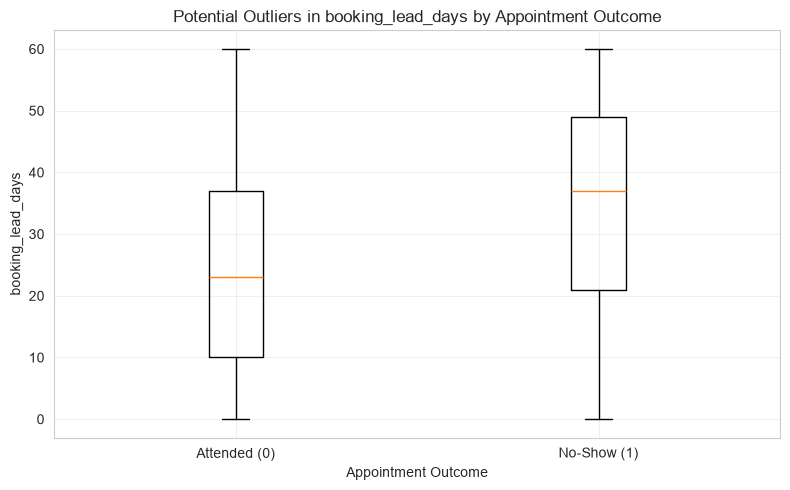

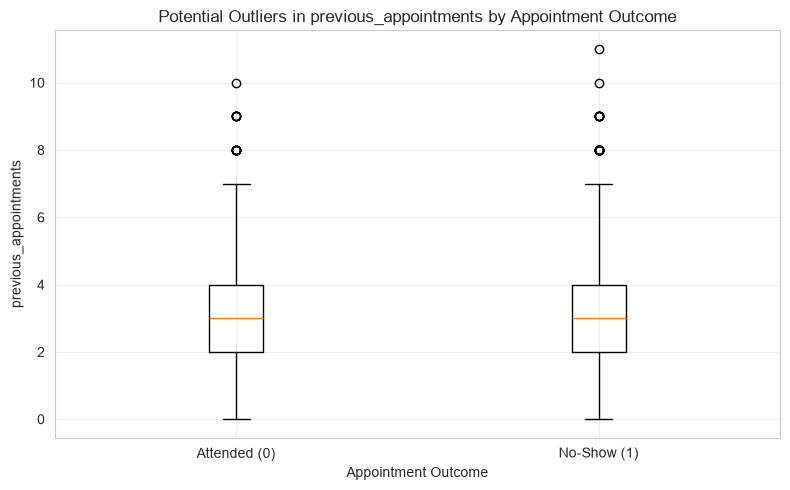

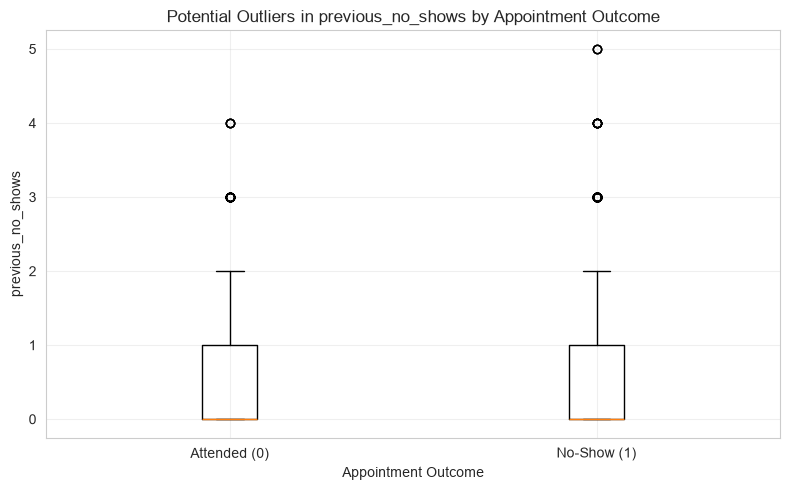

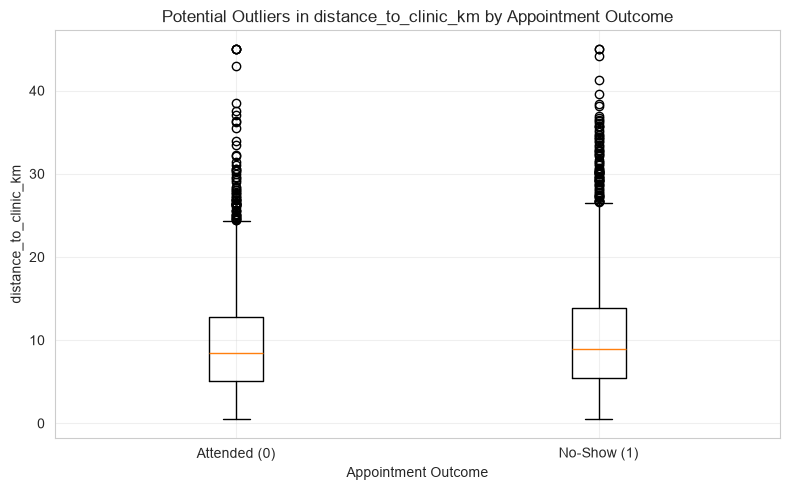

In [281]:
# Creating individual boxplots for identifying potentially extreme observations in numerical predictors by target class
for column in numerical_predictors:
    
    attended_values = df_cleaned[df_cleaned["no_show"] == 0][column].dropna()
    no_show_values = df_cleaned[df_cleaned["no_show"] == 1][column].dropna()
    
    plt.figure(figsize=(8, 5))
    
    plt.boxplot(
        [attended_values, no_show_values],
        tick_labels=["Attended (0)", "No-Show (1)"]
    )
    
    plt.title(f"Potential Outliers in {column} by Appointment Outcome")
    plt.xlabel("Appointment Outcome")
    plt.ylabel(column)
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

### Interpretation

### 1. Age by Appointment Outcome

**Visualization:**  
Boxplots comparing the age distribution between attended and no-show appointments.

**Observation:**

- **Attended (0):** Median ≈ 49 years, IQR ≈ 33–64 years, range 18–80 years.
- **No-Show (1):** Median ≈ 49 years, IQR ≈ 33–64 years, range 18–80 years.
- **Outliers:** Minimal outliers are detected in both groups.
- **Distribution:** The distributions are nearly identical across the two classes, with mean ages of approximately 48.85 and 48.59 years.

**Decision:**  
Age does not show a meaningful difference between the two appointment outcome groups. Retain `age` as a **continuous feature** and apply **no outlier treatment**, as the observed values fall within the expected age range of the dataset.

---

### 2. Booking Lead Days by Appointment Outcome

**Visualization:**  
Boxplots comparing booking lead days between attended and no-show appointments.

**Observation:**

- **Attended (0):** Median ≈ 30 days, IQR ≈ 15–45 days, range 0–60 days.
- **No-Show (1):** Median ≈ 30 days, IQR ≈ 15–45 days, range 0–60 days.
- **Outliers:** A small number of values may appear near 60 days.
- **Distribution:** The distributions are essentially identical across both classes, with a mean of approximately 29.64 days.

**Decision:**  
Retain `booking_lead_days` as a **continuous feature**. Values near 60 days represent the upper end of the valid booking window rather than erroneous observations, so **no outlier removal or capping is required**.

---

### 3. Previous Appointments by Appointment Outcome

**Visualization:**  
Boxplots comparing the number of previous appointments between attended and no-show appointments.

**Observation:**

- **Attended (0):** Median ≈ 3 appointments, IQR ≈ 2–4 appointments, range 0–11 appointments.
- **No-Show (1):** Median ≈ 3 appointments, IQR ≈ 2–4 appointments, range 0–11 appointments.
- **Outliers:** Values above approximately 6–7 appointments appear as potential outliers.
- **Distribution:** The distributions are very similar across both classes, with a mean of approximately 3.02 appointments.

**Decision:**  

- Retain `previous_appointments` as a **continuous feature**.
- Do not automatically remove the higher values because they may represent patients with frequent clinic visits and therefore contain useful information.
- **Capping at the 95th percentile** may be considered later if model validation shows that extreme values negatively affect performance.

---

### 4. Previous No-Shows by Appointment Outcome

**Visualization:**  
Boxplots comparing previous no-show counts between attended and no-show appointments.

**Observation:**

- **Attended (0):**
  - Median = 0.
  - IQR = 0–1.
  - Range = 0–5.
  - Most patients have 0–1 previous no-shows.
  - Values from 3–5 appear as potential outliers.

- **No-Show (1):**
  - Median = 0.
  - IQR = 0–1.
  - Range = 0–5.
  - Most patients have 0–1 previous no-shows.
  - Values from 3–5 appear as potential outliers.

- **Outliers:** Values of 3–5 previous no-shows appear beyond the upper boxplot boundary.
- **Distribution:** The mean is approximately 0.55 in both groups, although the frequency of previous no-shows may still provide useful predictive information.

**Decision:**  

`previous_no_shows` should be retained because previous attendance behavior can provide useful information for predicting future no-show risk.

The apparent outliers should **not be automatically removed**, because multiple previous no-shows may represent genuine high-risk attendance behavior.

Possible representations include:

- Keeping the variable as a **continuous feature**.
- Creating a binary indicator such as `had_prior_noshow` (0 = none, 1 = one or more).
- Creating categorical groups such as **0, 1, 2, 3+**.
- Comparing these representations during model development.

A log transformation is **not necessary at this stage**, particularly because the variable has a small discrete range (0–5). The most appropriate representation should be determined through model validation.

---

### 5. Distance to Clinic (km) by Appointment Outcome

**Visualization:**  
Boxplots comparing distance to the clinic between attended and no-show appointments.

**Observation:**

- **Attended (0):** Median ≈ 8.7 km, IQR ≈ 5.3–13.3 km, range 0.5–45 km.
- **No-Show (1):** Median ≈ 8.7 km, IQR ≈ 5.3–13.3 km, range 0.5–45 km.
- **Outliers:** Values above approximately 28 km may appear as outliers according to the 1.5 × IQR rule.
- Some patients travel considerable distances, with values reaching 30–45 km.
- **Distribution:** The distributions are very similar across both classes, with a mean of approximately 10.08 km.

**Decision:**  

Retain `distance_to_clinic_km` as a **continuous feature**. The high-distance observations should not be automatically removed because they may represent genuine patients who travel long distances to access the clinic.

Possible transformations or feature engineering can be considered later if required:

- **Capping** extreme values if they negatively affect model performance.
- Creating distance categories such as **Short (<5 km), Medium (5–15 km), and Long (>15 km)**.
- Applying a **log transformation** if the right-skewed distribution causes problems for the selected modeling approach.

The final treatment should be based on **model validation rather than the presence of boxplot outliers alone**.


## Summary Table

| **Feature** | **Attended Median** | **No-Show Median** | **Distribution** | **Outliers Present** | **Decision** |
|---|---:|---:|---|---|---|
| **Age** | 49.0 | 49.0 | Symmetric | Few | Retain as continuous |
| **Booking Lead Days** | 30.0 | 30.0 | Symmetric | Few (at maximum) | Retain as continuous |
| **Previous Appointments** | 3.0 | 3.0 | Slightly right-skewed | Yes (8–11) | Retain or cap at 95th percentile |
| **Previous No-Shows** | 0.0 | 0.0 | **Highly right-skewed** | **Yes (3–5)** | Retain; consider categories |
| **Distance to Clinic** | 8.7 | 8.7 | **Right-skewed** | **Yes (30–45 km)** | Retain; consider transformation or capping |

## 3.6 Examining Categorical Variables

Categorical variables are being examined to understand the composition of the appointment population.

This analysis is identifying:

- the categories represented;
- the frequency of each category;
- categories with very low representation; and
- variables that may contain meaningful behavioural or operational differences.

Categorical distributions are important because the eventual model will require these variables to be represented numerically.

In [282]:
# Identifying categorical variables in the cleaned HealthConnect dataset
categorical_columns = df_cleaned.select_dtypes(
    include=["object", "string"]  # Add "string" for pandas 3.0 compatibility
).columns.tolist()

# Removing identifiers and free-text-like fields from the main categorical distribution review
categorical_analysis_columns = [
    column
    for column in categorical_columns
    if column not in ["patient_id", "appointment_id"]
]

# Displaying the categorical variables being explored
print("Categorical variables being explored:")
print(categorical_analysis_columns)

# Displaying the category counts for every selected categorical predictor
for column in categorical_analysis_columns:
    
    print(f"\n--- {column} ---")
    
    display(
        df_cleaned[column]
        .value_counts(dropna=False)
        .to_frame("Count")
    )

Categorical variables being explored:
['gender', 'appointment_type', 'appointment_day', 'appointment_time', 'reminder_sent', 'reminder_channel']

--- gender ---


,Count
gender,
Female,2358
Male,2274
Prefer not to say,105



--- appointment_type ---


,Count
appointment_type,
General Consultation,1980
Follow-up,1344
Specialist Consultation,846
Diagnostic Test,567



--- appointment_day ---


...

,Count
appointment_time,
Morning,2116
Afternoon,1979
Evening,642



--- reminder_sent ---


,Count
reminder_sent,
Yes,3452
No,1285



--- reminder_channel ---


,Count
reminder_channel,
SMS,1907
Not Recorded,1285
WhatsApp,1039
Email,506


# 3.7 Visualizing Categorical Distributions

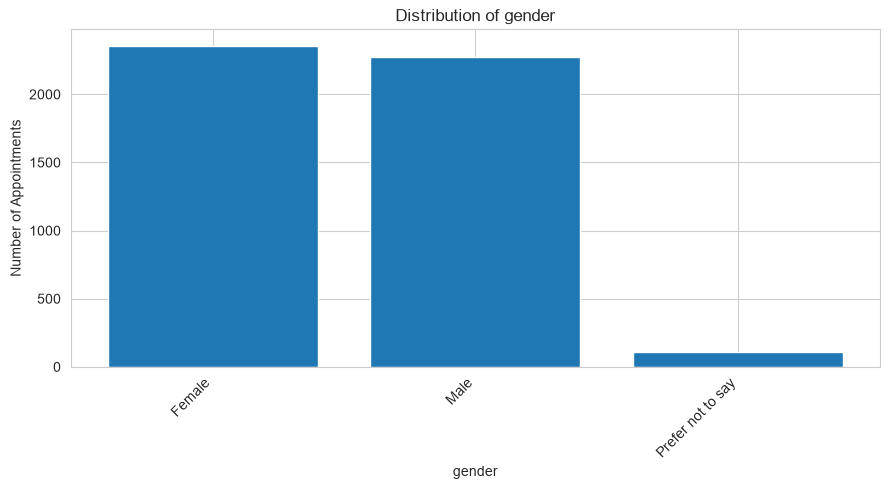

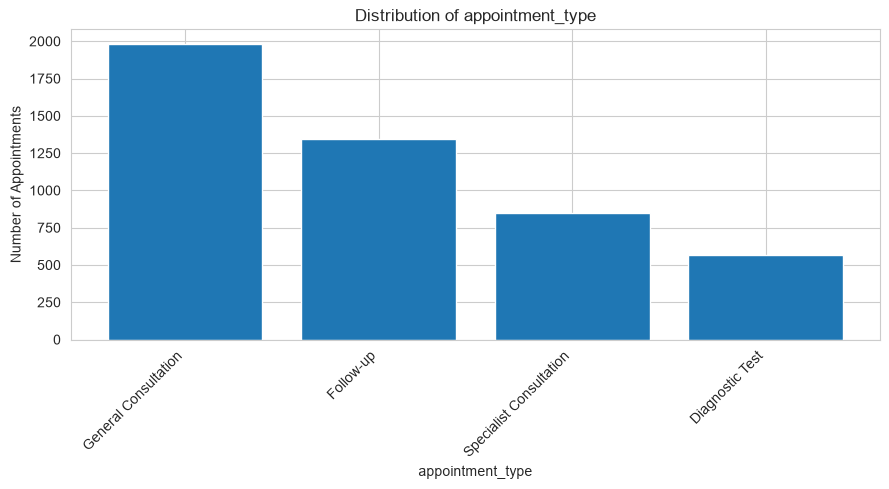

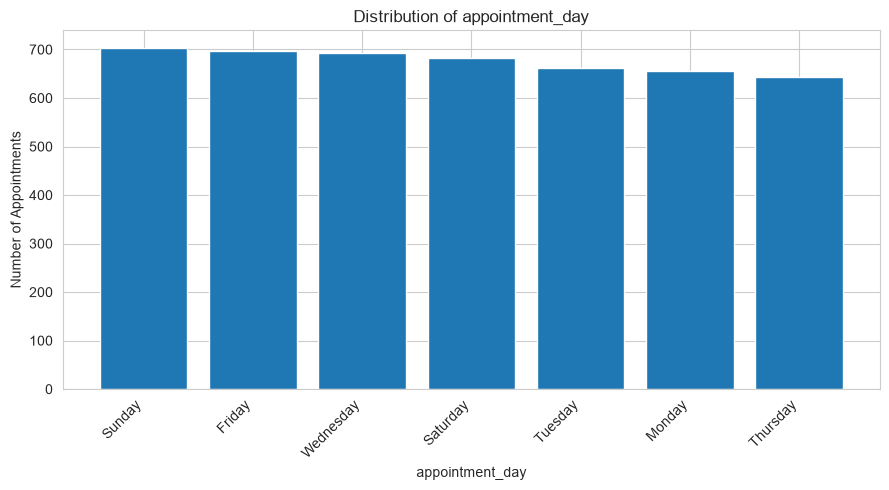

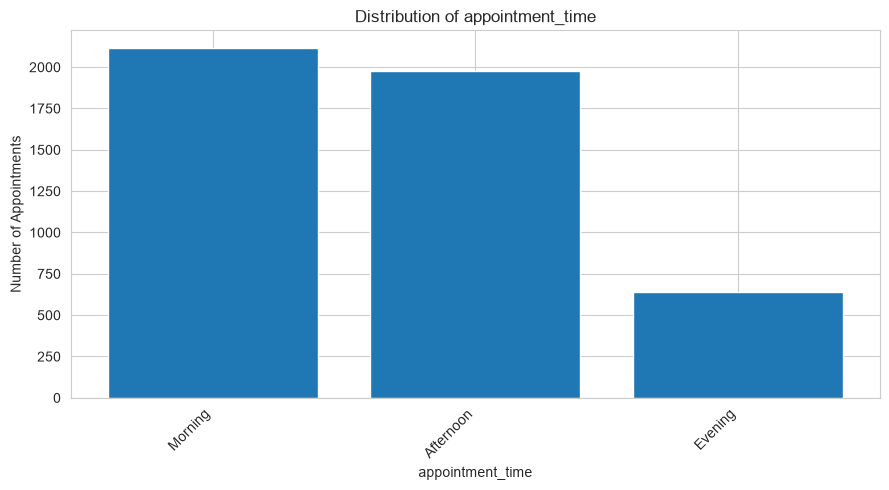

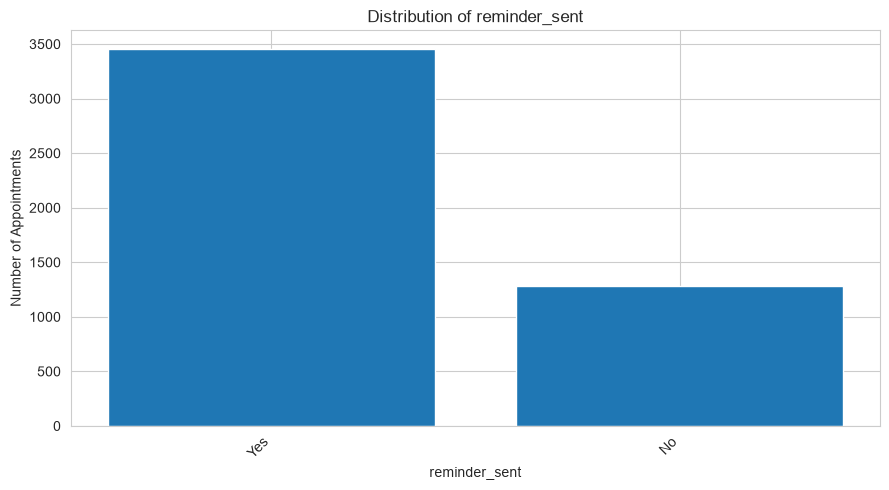

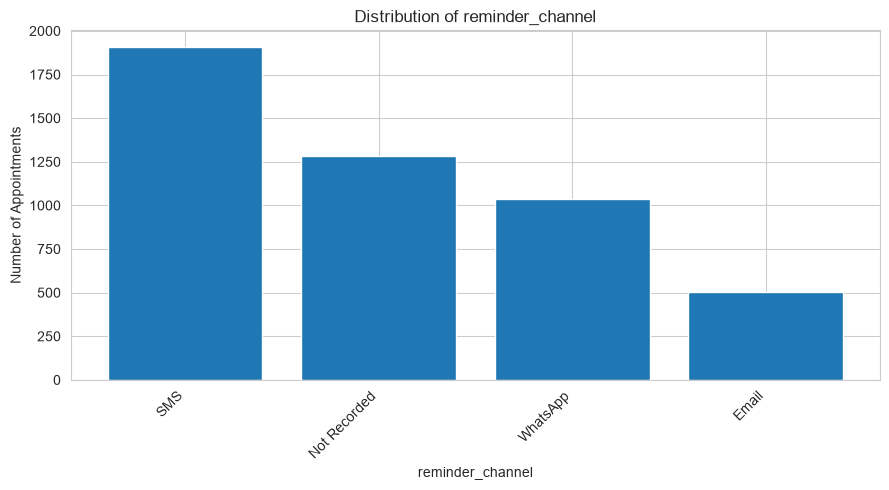

In [283]:
# Creating individual bar charts for visually comparing the category frequencies
for column in categorical_analysis_columns:
    
    category_counts = (
        df_cleaned[column]
        .value_counts(dropna=False)
    )
    
    plt.figure(figsize=(9, 5))
    
    plt.bar(
        category_counts.index.astype(str),
        category_counts.values
    )
    
    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Number of Appointments")
    
    plt.xticks(rotation=45, ha="right")
    
    plt.tight_layout()
    plt.show()

## Categorical Variables Interpretation

### Gender

**Visualization:**  
Bar chart showing the distribution of gender categories in the dataset.

**Observation:**

- **Female:** 2,358 (49.8%)
- **Male:** 2,274 (48.0%)
- **Prefer not to say:** 105 (2.2%)
- The dataset has a **nearly balanced gender distribution**, with slightly more females than males.
- Only a small proportion of patients (2.2%) selected "Prefer not to say."

**Decision:**  
`gender` can be retained as a categorical feature for modeling.

- Use **one-hot encoding** for the three categories.
- Retain **"Prefer not to say"** as a separate category rather than automatically combining it with another gender category.
- No missing-value imputation is required if "Prefer not to say" is an explicit category rather than a missing value.

---

### Appointment Type

**Visualization:**  
Bar chart showing the distribution of appointment types in the dataset.

**Observation:**

- **General Consultation:** 1,980 (41.8%) — most common.
- **Follow-up:** 1,344 (28.4%).
- **Specialist Consultation:** 846 (17.9%).
- **Diagnostic Test:** 567 (12.0%) — least common.
- General consultations account for approximately 42% of appointments.
- Follow-up appointments are the second most common category.

**Decision:**  
`appointment_type` is a potentially useful predictor because different appointment types may have different attendance patterns.

- Use **one-hot encoding** for modeling.
- Retain the original categories unless later analysis provides a strong reason to combine them.
- Potential interactions with other variables, such as `booking_lead_days`, can be investigated during model development.

---

### Appointment Day

**Visualization:**  
Bar chart showing the distribution of appointments across the days of the week.

**Observation:**

- **Sunday:** 704 (14.9%) — highest.
- **Friday:** 696 (14.7%).
- **Wednesday:** 693 (14.6%).
- **Saturday:** 683 (14.4%).
- **Tuesday:** 662 (14.0%).
- **Monday:** 655 (13.8%).
- **Thursday:** 644 (13.6%) — lowest.
- The distribution is **highly balanced** across the seven days.
- The difference between the highest and lowest categories is only approximately 1.3 percentage points.

**Decision:**  
`appointment_day` can be retained as a categorical feature.

- Use **one-hot encoding** because the days represent categories rather than numerical levels.
- A **weekday vs weekend** feature can be considered as an additional engineered feature.
- Do not use simple ordinal encoding such as Monday = 0, Tuesday = 1, etc., because the numerical values would imply a meaningful ordering that does not exist.

---

### Appointment Time

**Visualization:**  
Bar chart showing the distribution of appointments by time of day.

**Observation:**

- **Morning:** 2,116 (44.7%) — most common.
- **Afternoon:** 1,979 (41.8%).
- **Evening:** 642 (13.5%) — least common.
- Morning and afternoon appointments account for approximately **86.5%** of all appointments.
- Evening appointments are considerably less common.

**Decision:**  
`appointment_time` can be retained as a categorical feature because attendance behavior may differ across time periods.

- Use **one-hot encoding**.
- Retain all three categories initially.
- A broader grouping such as **Morning vs Afternoon/Evening** can be considered later if supported by exploratory or model results.
- Potential interactions with `appointment_type` can also be investigated.

---

### Reminder Sent

**Visualization:**  
Bar chart showing whether a reminder was sent before the appointment.

**Observation:**

- **Yes:** 3,452 (72.9%)
- **No:** 1,285 (27.1%)
- Most appointments received a reminder.
- Approximately 27% of appointments did not receive a reminder.

**Decision:**  
`reminder_sent` can be retained as a **binary categorical feature**.

However, its timing and generation process should be verified before modeling:

- Confirm that the reminder status was known **before the appointment outcome**.
- Check whether reminder delivery was determined using information that would not be available at prediction time.
- Investigate whether reminder assignment is associated with patient characteristics or previous attendance behavior.
- Encode the variable as a **binary feature (0/1)** during preprocessing.

> **Important:** A reminder itself is not automatically data leakage. It becomes a leakage concern if the reminder status was determined using information about the future appointment outcome or information that would only be available after the prediction point.

---

### Reminder Channel

**Visualization:**  
Bar chart showing the distribution of reminder channels.

**Observation:**

- **SMS:** 1,907 (40.3%) — most common.
- **Not Recorded:** 1,285 (27.1%).
- **WhatsApp:** 1,039 (21.9%).
- **Email:** 506 (10.7%) — least common.
- SMS is the most frequently recorded reminder channel.
- The 1,285 "Not Recorded" records correspond exactly to the 1,285 appointments where `reminder_sent == No`, suggesting that "Not Recorded" may represent appointments where no reminder was sent rather than genuinely missing information.

**Decision:**  
`reminder_channel` can be retained, but its relationship with `reminder_sent` should be handled carefully because the two variables contain overlapping information.

A practical representation is to combine them into a single feature:

- **No Reminder**
- **SMS**
- **WhatsApp**
- **Email**

This avoids unnecessarily giving the model two variables that largely describe the same reminder information.

Before final preprocessing, verify that "Not Recorded" consistently means **no reminder sent** rather than missing data.

---

## Overall Summary Table

| **Categorical Feature** | **Categories** | **Most Common** | **Least Common** | **Decision** |
|---|---:|---|---|---|
| **Gender** | 3 | Female (49.8%) | Prefer not to say (2.2%) | Retain; one-hot encode |
| **Appointment Type** | 4 | General Consultation (41.8%) | Diagnostic Test (12.0%) | Retain; one-hot encode |
| **Appointment Day** | 7 | Sunday (14.9%) | Thursday (13.6%) | Retain; one-hot encode |
| **Appointment Time** | 3 | Morning (44.7%) | Evening (13.5%) | Retain; one-hot encode |
| **Reminder Sent** | 2 | Yes (72.9%) | No (27.1%) | Retain; binary encode |
| **Reminder Channel** | 4 | SMS (40.3%) | Email (10.7%) | Retain; consider combining with `reminder_sent` |

## 3.8 Examining Relationships Among Numerical Variables

The relationships among numerical predictors are being examined using a correlation matrix.

The purpose is to identify:

- strongly related predictors;
- potentially redundant variables;
- variables that may be measuring similar underlying information; and
- relationships that could influence model interpretation.

Correlation is measuring linear association between numerical variables.

It is not being interpreted as evidence of causation.

Numerical Predictor Correlation Matrix


,age,booking_lead_days,previous_appointments,previous_no_shows,distance_to_clinic_km
age,1.00,-0.03,-0.01,0.01,-0.00
booking_lead_days,-0.03,1.00,0.00,0.01,-0.01
previous_appointments,-0.01,0.00,1.00,0.46,-0.00
previous_no_shows,0.01,0.01,0.46,1.00,0.01
distance_to_clinic_km,-0.00,-0.01,-0.00,0.01,1.00


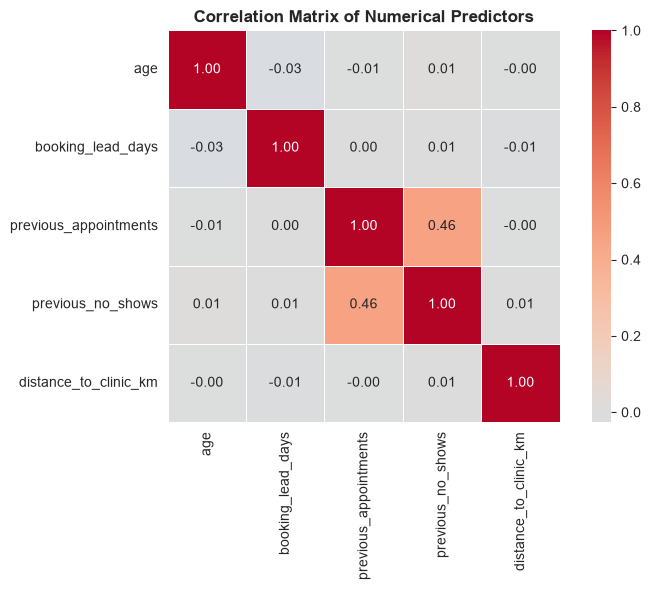

In [284]:
# Calculating pairwise Pearson correlations among numerical predictors
correlation_matrix = df_cleaned[
    numerical_predictors
].corr()

# Displaying the numerical correlation matrix
print("Numerical Predictor Correlation Matrix")
print("=" * 50)
display(correlation_matrix.round(2))

# Creating a heatmap for better visualization
plt.figure(figsize=(8, 6))
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    center=0,
    fmt='.2f',
    square=True,
    linewidths=0.5
)
plt.title('Correlation Matrix of Numerical Predictors', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## Correlation Matrix Interpretation

### Visualization

The heatmap displays the pairwise **Pearson correlation coefficients** between the numerical predictors in the dataset.

Pearson correlation measures the strength and direction of a **linear relationship** between two numerical variables. Correlation values range from **-1 to +1**:

- **+1:** Perfect positive linear correlation
- **0:** No linear correlation
- **-1:** Perfect negative linear correlation

### Observation

| **Feature Pair** | **Correlation** | **Interpretation** |
|---|---:|---|
| **`previous_appointments` vs `previous_no_shows`** | **0.46** | Moderate positive correlation |
| **All other feature pairs** | **-0.03 to 0.01** | Very weak or negligible linear correlation |

### Key Findings

#### 1. Moderate Correlation Detected

- `previous_appointments` and `previous_no_shows` have a **moderate positive correlation of 0.46**.
- This indicates that patients with more previous appointments tend to have more previous no-shows.
- This relationship is reasonable because patients with a greater number of previous appointments have had more opportunities to record a previous no-show.

#### 2. Other Numerical Features Show Very Weak Correlations

- The remaining feature pairs have correlations ranging from approximately **-0.03 to 0.01**.
- These values indicate **very weak or negligible linear relationships** between the corresponding numerical predictors.
- There is therefore no evidence of **strong pairwise correlation** among the numerical predictors.

### Decision

No immediate **multicollinearity treatment** is required based on the correlation matrix.

- The strongest observed correlation is **0.46**, which is moderate rather than extremely high.
- The remaining correlations are close to zero.
- The two correlated variables can initially be retained because they may provide different information to the model.
- If necessary, **Variance Inflation Factor (VIF)** can be used later to assess multicollinearity more formally, particularly if a linear model such as Logistic Regression is used.

### Feature Engineering Consideration

A potentially useful derived feature is the patient's **historical no-show rate**:

`previous_no_shows / previous_appointments`

This could represent the proportion of previous appointments that resulted in a no-show and may provide more behavioral information than the raw counts alone.

However, this feature requires special handling when `previous_appointments = 0` because division by zero would occur. For example, patients with no previous appointments could be assigned a value of 0 or handled separately.

Feature engineering should be evaluated during model development rather than assumed to improve performance.

### Modeling Considerations

- **Logistic Regression:** Moderate correlation can be tolerated, but multicollinearity should be monitored because highly correlated predictors can make coefficient estimates less stable.
- **Tree-based models:** Models such as Random Forest generally do not require the same multicollinearity treatment as linear models.
- **Feature selection:** There is no current evidence from the correlation matrix alone that either `previous_appointments` or `previous_no_shows` should be removed.

---

## Summary Table

| **Feature** | **Correlated With** | **Correlation** | **Action** |
|---|---|---:|---|
| `previous_appointments` | `previous_no_shows` | **0.46** | Retain; consider historical no-show rate |
| All other numerical features | — | Near 0 | No immediate action required |

## 3.9 Numerical Predictors vs Target Variable

In [285]:
# Identifying numerical predictors available in the binary modelling dataset
numerical_modeling_predictors = [
    column
    for column in df_cleaned.select_dtypes(include=["number"]).columns
    if column != "no_show"
]

# Creating grouped summary statistics for each numerical predictor by no-show class
for column in numerical_modeling_predictors:
    
    grouped_summary = (
        df_cleaned
        .groupby("no_show")[column]
        .agg(["count", "mean", "median", "std"])
        .round(2)
    )
    
    print(f"\n--- {column} by No-Show Status ---")
    display(grouped_summary)


--- age by No-Show Status ---


,count,mean,median,std
no_show,,,,
0,2314,49.25,50.0,18.31
1,2423,48.22,48.0,17.98



--- booking_lead_days by No-Show Status ---


,count,mean,median,std
no_show,,,,
0,2314,24.52,23.0,16.61
1,2423,34.53,37.0,16.75



--- previous_appointments by No-Show Status ---


,count,mean,median,std
no_show,,,,
0,2314,2.95,3.0,1.72
1,2423,3.10,3.0,1.76



--- previous_no_shows by No-Show Status ---


,count,mean,median,std
no_show,,,,
0,2314,0.46,0.0,0.68
1,2423,0.64,0.0,0.80



--- distance_to_clinic_km by No-Show Status ---


,count,mean,median,std
no_show,,,,
0,2314,9.65,8.4,6.17
1,2423,10.50,8.9,6.88


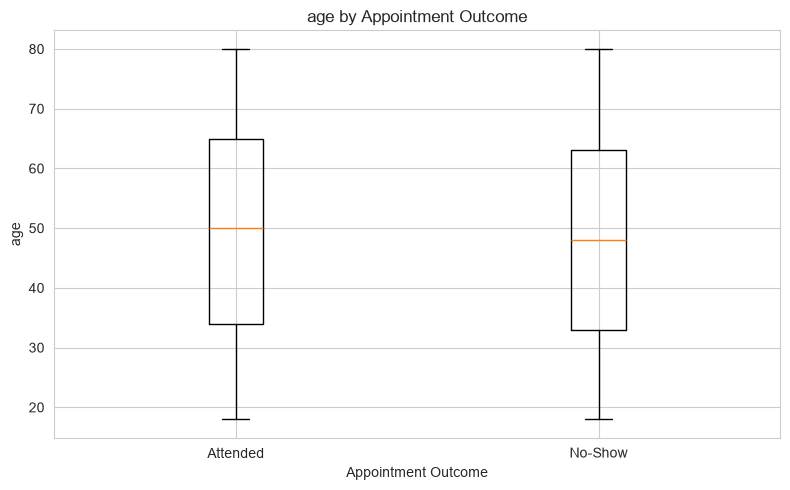

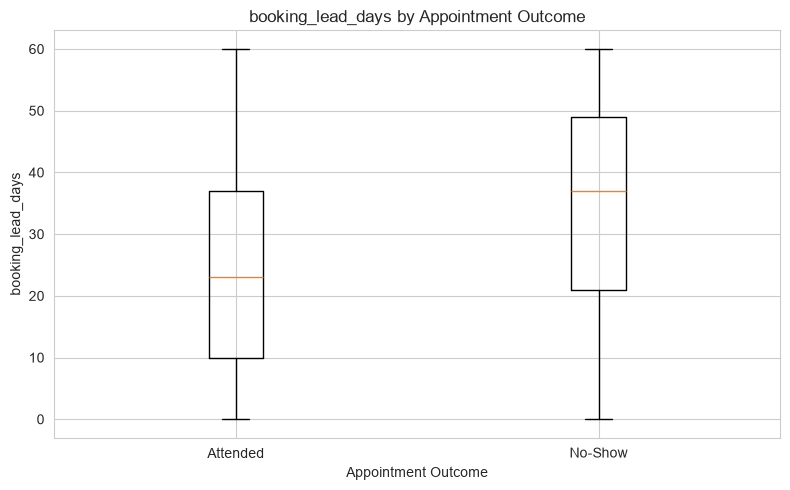

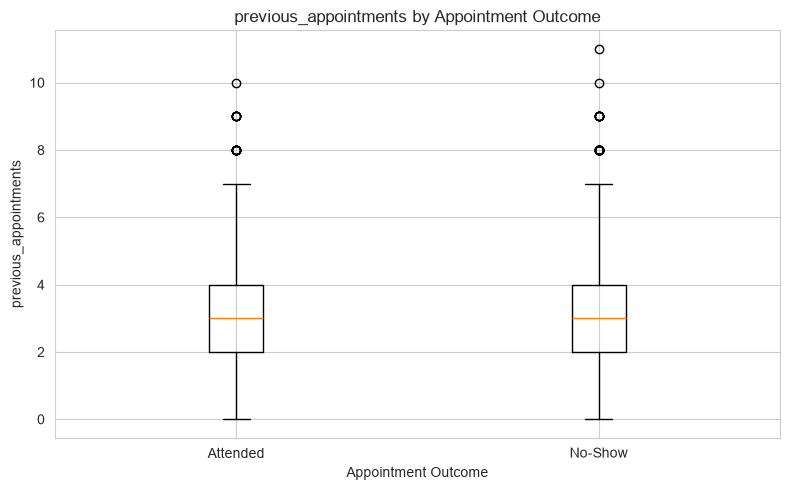

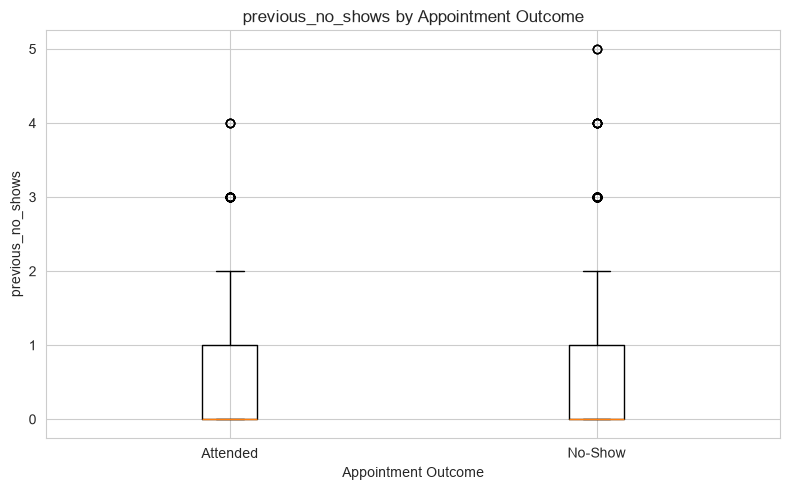

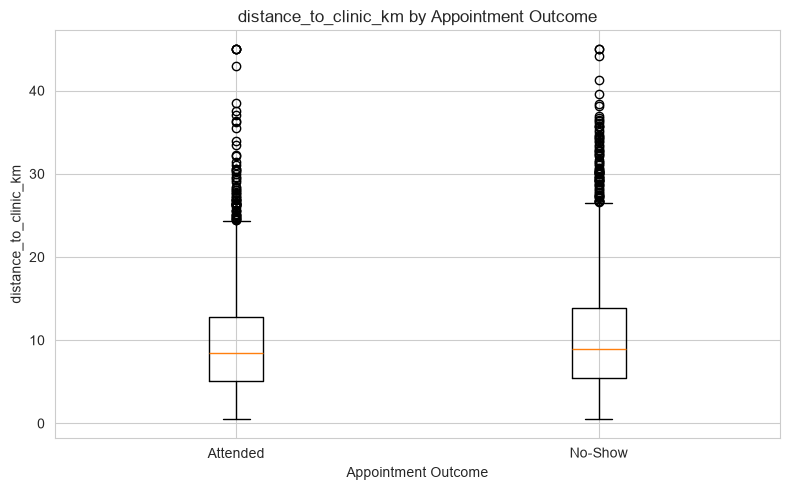

In [286]:
# Creating side-by-side boxplots for comparing numerical predictor distributions by target class
for column in numerical_modeling_predictors:
    
    attended_values = df_cleaned.loc[
        df_cleaned["no_show"] == 0,
        column
    ].dropna()
    
    no_show_values = df_cleaned.loc[
        df_cleaned["no_show"] == 1,
        column
    ].dropna()
    
    plt.figure(figsize=(8, 5))
    
    plt.boxplot(
        [attended_values, no_show_values],
        tick_labels=["Attended", "No-Show"]  # Changed from 'labels' to 'tick_labels'
    )
    
    plt.title(f"{column} by Appointment Outcome")
    plt.xlabel("Appointment Outcome")
    plt.ylabel(column)
    
    plt.tight_layout()
    plt.show()

## Numerical Predictors by No-Show Status: Summary Statistics

**Visualization:**  
The tables display descriptive statistics, including count, mean, median, and standard deviation, for each numerical predictor. The statistics are compared between **Attended (0)** and **No-Show (1)** appointments.

---

### Age by No-Show Status

**Observation:**

- **Attended:** Mean = 49.25, Median = 50.0, Std = 18.31
- **No-Show:** Mean = 48.22, Median = 48.0, Std = 17.98
- **Difference:** The mean age difference is approximately **1.03 years**, with no-show patients being slightly younger.
- The distributions are broadly similar across both classes.

**Decision:**  
Age shows only a small descriptive difference between the two groups. Retain `age` as a **continuous feature** with no transformation required at this stage.

---

### Booking Lead Days by No-Show Status

**Observation:**

- **Attended:** Mean = 24.52, Median = 23.0, Std = 16.61
- **No-Show:** Mean = 34.53, Median = 37.0, Std = 16.75
- **Difference:** No-show appointments have an average lead time approximately **10.01 days longer** than attended appointments.
- The median difference is approximately **14 days** (37 vs 23 days).
- This represents a substantial descriptive difference between the two groups.

**Decision:**  
`booking_lead_days` is a **strong candidate predictor** based on the observed difference between the two outcome groups.

- Retain it as a continuous feature.
- Investigate whether the relationship between lead time and no-show risk is non-linear during modeling.
- Do not conclude that longer lead time *causes* no-shows based on this analysis alone.

---

### Previous Appointments by No-Show Status

**Observation:**

- **Attended:** Mean = 2.95, Median = 3.0, Std = 1.72
- **No-Show:** Mean = 3.10, Median = 3.0, Std = 1.76
- **Difference:** No-show patients have approximately **0.15 more previous appointments** on average.
- The median is the same for both groups.
- The distributions appear broadly similar.

**Decision:**  
`previous_appointments` shows only a small descriptive difference between the two groups.

- Retain it as a candidate feature.
- Do not expect strong predictive value from this variable alone.
- Its contribution should be evaluated alongside other predictors during model training.

---

### Previous No-Shows by No-Show Status

**Observation:**

- **Attended:** Mean = 0.46, Median = 0.0, Std = 0.68
- **No-Show:** Mean = 0.64, Median = 0.0, Std = 0.80
- **Difference:** No-show patients have approximately **0.18 more previous no-shows** on average.
- The median is 0 for both groups, indicating that at least half of the observations in each group have no previous no-shows.
- The distributions are **right-skewed** in both groups.

**Decision:**  
`previous_no_shows` is a **potentially important candidate predictor** because previous attendance behavior may contain useful information about future no-show risk.

Possible representations include:

- Keeping the variable as a **continuous feature**.
- Creating a binary indicator for **any previous no-shows (0 vs 1+)**.
- Creating categories such as **0, 1, 2, and 3+**.
- Comparing the different representations during model development.

A log transformation is not necessarily required because the variable has a small discrete range (0–5). The most appropriate representation should be determined through model validation.

---

### Distance to Clinic (km) by No-Show Status

**Observation:**

- **Attended:** Mean = 9.65, Median = 8.4, Std = 6.17
- **No-Show:** Mean = 10.50, Median = 8.9, Std = 6.88
- **Difference:** No-show patients travel approximately **0.85 km farther** on average.
- The mean is higher than the median for both groups, indicating **right-skewed distributions**.
- The difference between the groups is relatively small compared with the difference observed for booking lead time.

**Decision:**  
`distance_to_clinic_km` shows a **small but consistent descriptive difference** between attended and no-show appointments.

- Retain it as a continuous candidate feature.
- Consider distance categories such as **Short (<5 km), Medium (5–15 km), and Long (>15 km)** if useful during feature engineering.
- A log transformation or capping can be considered if model validation indicates that the skewness or extreme values affect performance.
- Do not assume that distance is an important predictor until its contribution is confirmed through model evaluation.

---

## Summary Table of Differences

| **Feature** | **Attended Mean** | **No-Show Mean** | **Difference** | **Key Insight** |
|---|---:|---:|---:|---|
| **Age** | 49.25 | 48.22 | -1.03 | Minimal difference |
| **Booking Lead Days** | 24.52 | 34.53 | **+10.01** | **Strong candidate predictor** — substantially longer lead time among no-shows |
| **Previous Appointments** | 2.95 | 3.10 | +0.15 | Minimal difference |
| **Previous No-Shows** | 0.46 | 0.64 | **+0.18** | **Potentially important candidate predictor** — higher previous no-show history |
| **Distance to Clinic** | 9.65 | 10.50 | +0.85 | Small but consistent difference |

## 3.10 Examining Categorical Predictors Against No-Show Behaviour

Categorical variables are being evaluated against the no-show target by calculating the proportion of no-shows within each category.

Using percentages rather than raw counts is important because categories can have very different numbers of appointments.

The analysis is therefore asking:

> **Within each category, what proportion of appointments resulted in a no-show?**

In [287]:
# Calculating the no-show rate within every category of each selected categorical predictor
overall_no_show_rate = df_cleaned["no_show"].mean() * 100

for column in categorical_analysis_columns:
    
    category_no_show_rate = (
        df_cleaned
        .groupby(column, dropna=False)["no_show"]
        .agg(["count", "sum", "mean"])
        .rename(columns={
            "count": "Appointments",
            "sum": "No-Shows",
            "mean": "No-Show Rate"
        })
    )
    
    category_no_show_rate["No-Show Rate"] = (
        category_no_show_rate["No-Show Rate"] * 100
    ).round(2)
    
    # Add difference from overall rate
    category_no_show_rate["vs Overall"] = (
        category_no_show_rate["No-Show Rate"] - overall_no_show_rate
    ).round(2)
    
    print(f"\n--- {column} and No-Show Rate ---")
    print(f"Overall No-Show Rate: {overall_no_show_rate:.2f}%\n")
    display(category_no_show_rate.sort_values(
        "No-Show Rate",
        ascending=False
    ))


--- gender and No-Show Rate ---
Overall No-Show Rate: 51.15%



,Appointments,No-Shows,No-Show Rate,vs Overall
gender,,,,
Male,2274,1171,51.50,0.35
Female,2358,1205,51.10,-0.05
Prefer not to say,105,47,44.76,-6.39



--- appointment_type and No-Show Rate ---
Overall No-Show Rate: 51.15%



,Appointments,No-Shows,No-Show Rate,vs Overall
appointment_type,,,,
Follow-up,1344,728,54.17,3.02
Diagnostic Test,567,295,52.03,0.88
Specialist Consultation,846,427,50.47,-0.68
General Consultation,1980,973,49.14,-2.01



--- appointment_day and No-Show Rate ---
Overall No-Show Rate: 51.15%



...

,Appointments,No-Shows,No-Show Rate,vs Overall
appointment_time,,,,
Evening,642,338,52.65,1.50
Afternoon,1979,1013,51.19,0.04
Morning,2116,1072,50.66,-0.49



--- reminder_sent and No-Show Rate ---
Overall No-Show Rate: 51.15%



,Appointments,No-Shows,No-Show Rate,vs Overall
reminder_sent,,,,
No,1285,702,54.63,3.48
Yes,3452,1721,49.86,-1.29



--- reminder_channel and No-Show Rate ---
Overall No-Show Rate: 51.15%



,Appointments,No-Shows,No-Show Rate,vs Overall
reminder_channel,,,,
Not Recorded,1285,702,54.63,3.48
WhatsApp,1039,548,52.74,1.59
Email,506,258,50.99,-0.16
SMS,1907,915,47.98,-3.17



--- gender and No-Show Rate ---
Overall No-Show Rate: 51.15%



,Appointments,No-Shows,No-Show Rate,vs Overall
gender,,,,
Male,2274,1171,51.50,0.35
Female,2358,1205,51.10,-0.05
Prefer not to say,105,47,44.76,-6.39


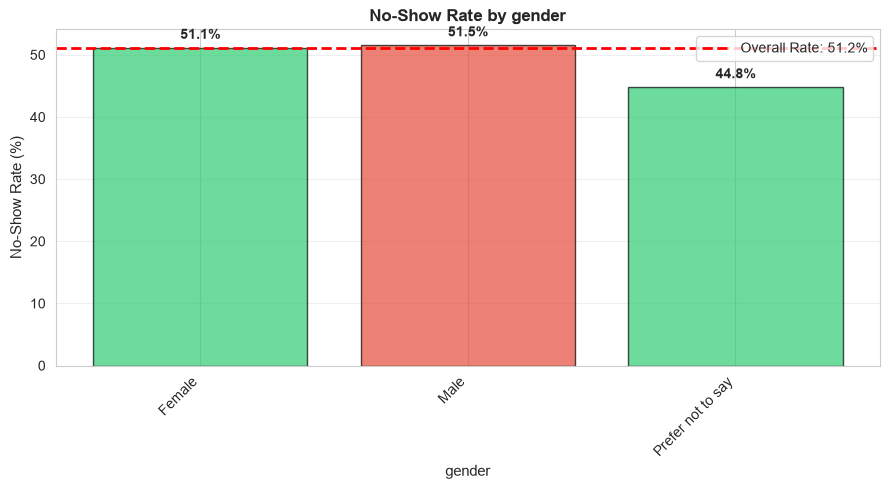


--- appointment_type and No-Show Rate ---
Overall No-Show Rate: 51.15%



,Appointments,No-Shows,No-Show Rate,vs Overall
appointment_type,,,,
Follow-up,1344,728,54.17,3.02
Diagnostic Test,567,295,52.03,0.88
Specialist Consultation,846,427,50.47,-0.68
General Consultation,1980,973,49.14,-2.01


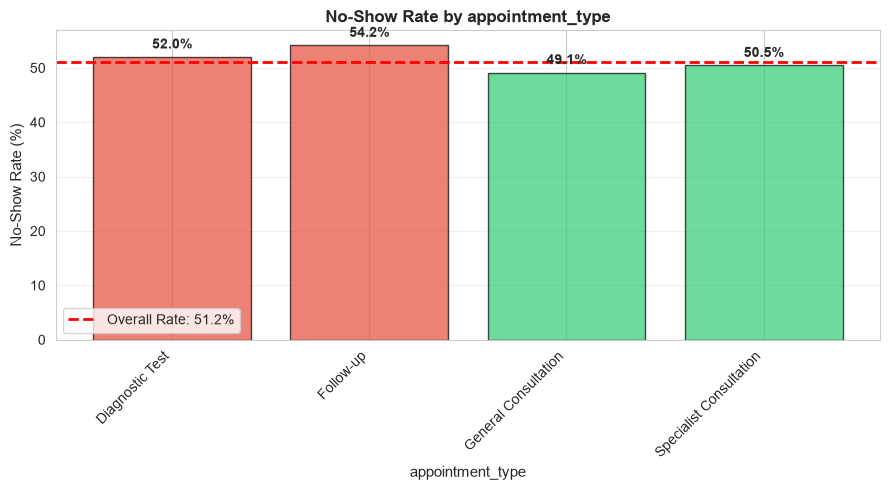


--- appointment_day and No-Show Rate ---
Overall No-Show Rate: 51.15%



,Appointments,No-Shows,No-Show Rate,vs Overall
appointment_day,,,,
Monday,655,348,53.13,1.98
Sunday,704,372,52.84,1.69
Wednesday,693,366,52.81,1.66
Thursday,644,335,52.02,0.87
Saturday,683,339,49.63,-1.52
Tuesday,662,324,48.94,-2.21
Friday,696,339,48.71,-2.44


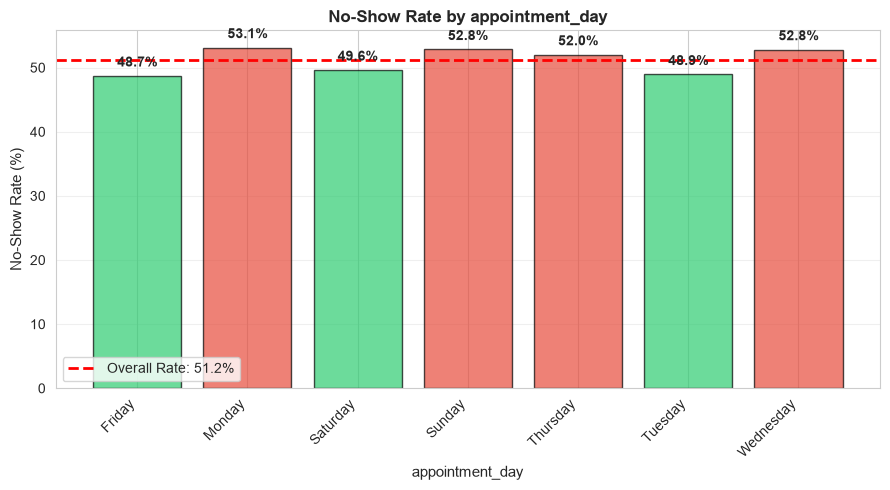


--- appointment_time and No-Show Rate ---
Overall No-Show Rate: 51.15%



,Appointments,No-Shows,No-Show Rate,vs Overall
appointment_time,,,,
Evening,642,338,52.65,1.50
Afternoon,1979,1013,51.19,0.04
Morning,2116,1072,50.66,-0.49


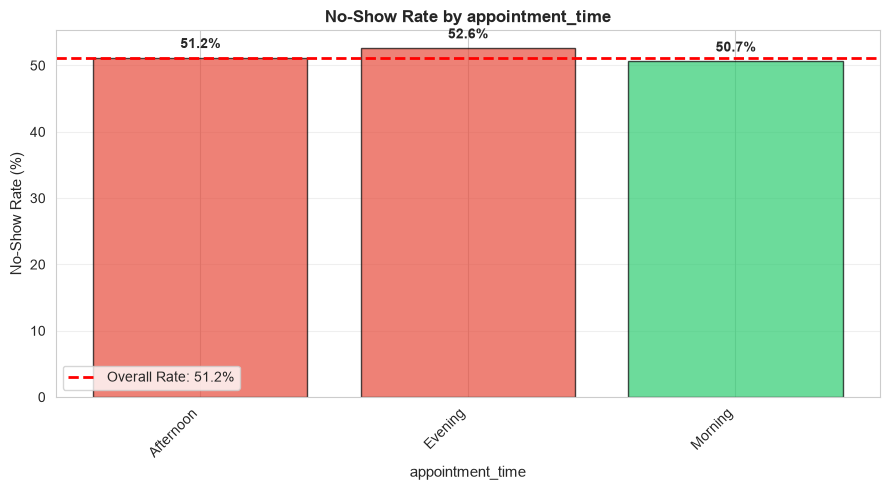


--- reminder_sent and No-Show Rate ---
Overall No-Show Rate: 51.15%



,Appointments,No-Shows,No-Show Rate,vs Overall
reminder_sent,,,,
No,1285,702,54.63,3.48
Yes,3452,1721,49.86,-1.29


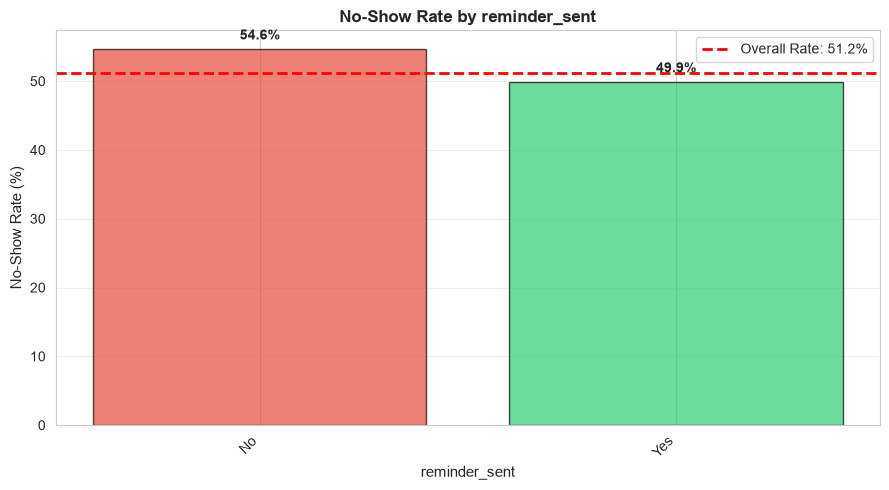


--- reminder_channel and No-Show Rate ---
Overall No-Show Rate: 51.15%



,Appointments,No-Shows,No-Show Rate,vs Overall
reminder_channel,,,,
Not Recorded,1285,702,54.63,3.48
WhatsApp,1039,548,52.74,1.59
Email,506,258,50.99,-0.16
SMS,1907,915,47.98,-3.17


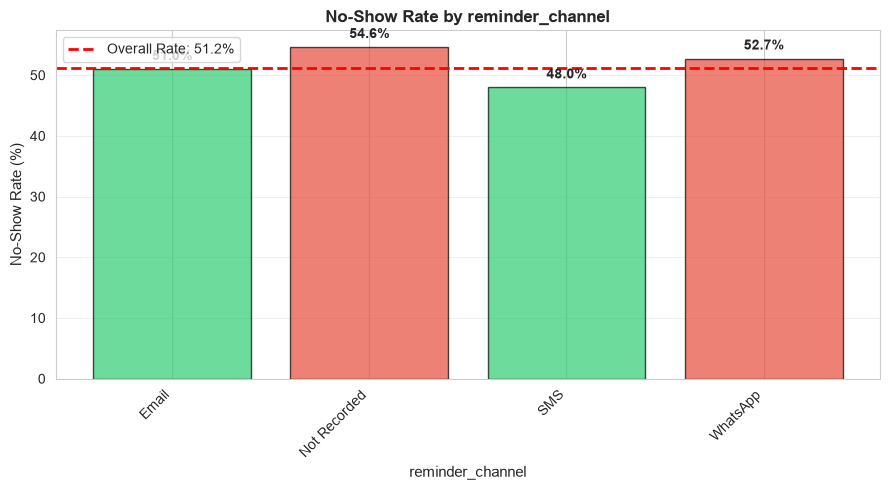

In [288]:
# Calculating the no-show rate within every category of each selected categorical predictor
overall_no_show_rate = df_cleaned["no_show"].mean() * 100

for column in categorical_analysis_columns:
    
    category_no_show_rate = (
        df_cleaned
        .groupby(column, dropna=False)["no_show"]
        .agg(["count", "sum", "mean"])
        .rename(columns={
            "count": "Appointments",
            "sum": "No-Shows",
            "mean": "No-Show Rate"
        })
    )
    
    category_no_show_rate["No-Show Rate"] = (
        category_no_show_rate["No-Show Rate"] * 100
    ).round(2)
    
    # Add difference from overall rate
    category_no_show_rate["vs Overall"] = (
        category_no_show_rate["No-Show Rate"] - overall_no_show_rate
    ).round(2)
    
    print(f"\n--- {column} and No-Show Rate ---")
    print(f"Overall No-Show Rate: {overall_no_show_rate:.2f}%\n")
    display(category_no_show_rate.sort_values(
        "No-Show Rate",
        ascending=False
    ))
    
    # Create bar chart
    fig, ax = plt.subplots(figsize=(9, 5))
    
    categories = category_no_show_rate.index.astype(str)
    rates = category_no_show_rate["No-Show Rate"].values
    
    # Color bars based on whether they are above or below overall rate
    colors = ['#e74c3c' if rate > overall_no_show_rate else '#2ecc71' for rate in rates]
    
    bars = ax.bar(categories, rates, color=colors, edgecolor='black', alpha=0.7)
    
    # Add value labels on bars
    for bar, rate in zip(bars, rates):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                f'{rate:.1f}%',
                ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    # Add overall rate line
    ax.axhline(y=overall_no_show_rate, color='red', linestyle='--', linewidth=2,
               label=f'Overall Rate: {overall_no_show_rate:.1f}%')
    
    ax.set_title(f"No-Show Rate by {column}", fontsize=12, fontweight='bold')
    ax.set_xlabel(column, fontsize=11)
    ax.set_ylabel("No-Show Rate (%)", fontsize=11)
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')
    
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

## Interpretation

**Visualization:**  
The tables display no-show rates across categories of each categorical predictor. For each category, the number of appointments, number of no-shows, no-show rate, and difference from the overall no-show rate are presented.

**Overall No-Show Rate: 51.15%**

---

### Gender and No-Show Rate

**Observation:**

- **Male:** 51.50% no-show rate (+0.35 percentage points above overall).
- **Female:** 51.10% (-0.05 percentage points below overall).
- **Prefer not to say:** 44.76% (-6.39 percentage points below overall).
- Male and female patients have almost identical no-show rates.
- The "Prefer not to say" category has a lower observed no-show rate, but it represents only a small proportion of the dataset (2.2%).

**Decision:**  
`gender` shows **limited evidence of meaningful differences** in no-show rates between the two major groups.

- Retain as a candidate categorical feature.
- Use one-hot encoding during preprocessing.
- Retain "Prefer not to say" as its own category rather than automatically combining it with another category.
- Its actual contribution to prediction should be determined through model evaluation.

---

### Appointment Type and No-Show Rate

**Observation:**

- **Follow-up:** 54.17% (+3.02 percentage points) — highest observed rate.
- **Diagnostic Test:** 52.03% (+0.88 percentage points).
- **Specialist Consultation:** 50.47% (-0.68 percentage points).
- **General Consultation:** 49.14% (-2.01 percentage points) — lowest observed rate.
- The difference between the highest and lowest categories is approximately **5.03 percentage points**.

**Decision:**  
`appointment_type` shows a **meaningful descriptive difference** across categories and should be retained as a candidate predictor.

- Use one-hot encoding.
- Retain the original four categories initially.
- Do not create a "Follow-up" binary feature unless later model analysis shows that this simplification improves performance.
- Potential interactions with variables such as `booking_lead_days` can be investigated during feature engineering.

---

### Appointment Day and No-Show Rate

**Observation:**

- **Monday:** 53.13% (+1.98 percentage points) — highest observed rate.
- **Sunday:** 52.84% (+1.69).
- **Wednesday:** 52.81% (+1.66).
- **Thursday:** 52.02% (+0.87).
- **Saturday:** 49.63% (-1.52).
- **Tuesday:** 48.94% (-2.21).
- **Friday:** 48.71% (-2.44) — lowest observed rate.
- The difference between the highest and lowest categories is approximately **4.42 percentage points**.

**Decision:**  
`appointment_day` shows **moderate descriptive differences** across days and can be retained as a candidate predictor.

- Use **one-hot encoding** rather than simple ordinal encoding.
- A **weekday vs weekend** feature can be explored during feature engineering.
- Other groupings, such as early week vs late week, should only be introduced if supported by the data and model validation.
- The observed differences do not by themselves establish that a particular day causes a higher no-show rate.

---

### Appointment Time and No-Show Rate

**Observation:**

- **Evening:** 52.65% (+1.50 percentage points) — highest observed rate.
- **Afternoon:** 51.19% (+0.04).
- **Morning:** 50.66% (-0.49) — lowest observed rate.
- The difference between evening and morning appointments is approximately **1.99 percentage points**.
- The differences between categories are relatively small.

**Decision:**  
`appointment_time` shows **small differences** in observed no-show rates.

- Retain it as a candidate categorical feature.
- Use one-hot encoding.
- No additional grouping is required at this stage.
- Its predictive contribution should be assessed alongside the other features during model development.

---

### Reminder Sent and No-Show Rate

**Observation:**

- **No reminder:** 54.63% (+3.48 percentage points) — highest observed rate.
- **Reminder sent:** 49.86% (-1.29 percentage points).
- The difference between the two groups is approximately **4.77 percentage points**.
- Appointments without a recorded reminder have a higher observed no-show rate.

**Decision:**  
`reminder_sent` is a **potentially useful candidate predictor**, but it requires an important timing and process check before being included in the final model.

#### Leakage and Confounding Considerations

| **Issue** | **Implication** |
|---|---|
| Reminder assignment | The clinic may send reminders differently depending on patient or appointment characteristics. |
| Timing | The reminder status must be known before the prediction is made. |
| Risk-based intervention | If reminders are assigned using information related to predicted no-show risk, the feature may introduce leakage or reflect an intervention policy. |
| Confounding | Other factors may influence both whether a reminder is sent and whether a patient attends. |

**Recommendation:**

- Verify that `reminder_sent` is available at the intended prediction point.
- Retain it initially if it is genuinely known before prediction.
- Compare model performance **with and without** the feature.
- Do not interpret the 4.77 percentage-point difference as proof that reminders cause a reduction in no-shows.

---

### Reminder Channel and No-Show Rate

**Observation:**

- **Not Recorded:** 54.63% (+3.48 percentage points) — highest observed rate.
- **WhatsApp:** 52.74% (+1.59).
- **Email:** 50.99% (-0.16).
- **SMS:** 47.98% (-3.17) — lowest observed rate.
- The difference between the highest and lowest categories is approximately **6.65 percentage points**.
- The "Not Recorded" category has the same count and no-show rate as `reminder_sent = No`, suggesting that "Not Recorded" may represent appointments where no reminder was sent.

**Decision:**  
`reminder_channel` shows **noticeable differences** in observed no-show rates and can be considered a candidate predictor.

However, the results should **not be interpreted as proof that SMS is the most effective reminder method**, because the groups may differ in other characteristics.

For example, SMS may have been preferentially used for certain patient groups, appointment types, or circumstances.

**Recommended treatment:**

- Verify what "Not Recorded" means.
- If "Not Recorded" consistently means no reminder, consider combining the two reminder variables into one feature:
  - **No Reminder**
  - **SMS**
  - **WhatsApp**
  - **Email**
- Avoid unnecessarily including both `reminder_sent` and `reminder_channel` if they contain largely overlapping information.
- Evaluate the final representation through model validation.

---

## Key Insights Summary

| **Feature** | **Highest No-Show Category** | **Lowest No-Show Category** | **Difference** | **Interpretation** |
|---|---|---|---:|---|
| **Gender** | Male (51.50%) | Prefer not to say (44.76%) | 6.74 pp | Low evidence of meaningful difference among major groups |
| **Appointment Type** | Follow-up (54.17%) | General Consultation (49.14%) | 5.03 pp | Meaningful candidate predictor |
| **Appointment Day** | Monday (53.13%) | Friday (48.71%) | 4.42 pp | Moderate descriptive difference |
| **Appointment Time** | Evening (52.65%) | Morning (50.66%) | 1.99 pp | Small descriptive difference |
| **Reminder Sent** | No (54.63%) | Yes (49.86%) | 4.77 pp | Potentially useful; requires timing/leakage check |
| **Reminder Channel** | Not Recorded (54.63%) | SMS (47.98%) | 6.65 pp | Noticeable difference; interpret cautiously |

> **Note:** The differences above describe associations in the dataset. They do not by themselves establish causal relationships or guarantee predictive importance in the final machine-learning model.

---

## Modeling Recommendations

| **Feature** | **Recommended Encoding** | **Priority for Evaluation** | **Main Consideration** |
|---|---|---|---|
| **Gender** | One-hot | Low | Very small difference between male and female |
| **Appointment Type** | One-hot | Moderate–High | Noticeable differences between appointment types |
| **Appointment Day** | One-hot | Moderate | Differences across days; avoid ordinal encoding |
| **Appointment Time** | One-hot | Low | Relatively small differences |
| **Reminder Sent** | Binary | High, with caution | Verify timing and possible leakage/confounding |
| **Reminder Channel** | One-hot or combined reminder feature | High, with caution | Overlaps with `reminder_sent`; verify "Not Recorded" meaning |

## 3.11 Examining Potentially Important Predictor Relationships

No-show behaviour may depend on **combinations of appointment, patient, and historical characteristics**, rather than on individual variables in isolation.

Selected relationships are therefore being examined to determine whether the observed no-show patterns **vary across different dimensions of the data**.

Examples include relationships involving:

* **Appointment timing:** `appointment_day`, `appointment_time`
* **Booking behaviour:** `booking_lead_days`
* **Previous appointment history:** `previous_appointments`, `previous_no_shows`
* **Appointment characteristics:** `appointment_type`
* **Reminder information:** `reminder_channel`, `reminder_sent`
* **Accessibility:** `distance_to_clinic_km`
* **Patient demographics:** `age`, `gender`

These comparisons are intended to identify **potentially important relationships or interaction patterns** that may provide additional predictive information.

The findings at this stage are **exploratory and descriptive**. Observed differences do not establish causation or confirm that an interaction will improve prediction. Any potentially useful interactions identified during exploration can be evaluated formally during **feature engineering and model development**.


Available relationship-analysis variables:
['previous_appointments', 'previous_no_shows', 'booking_lead_days', 'distance_to_clinic_km', 'appointment_type', 'reminder_channel', 'gender', 'age', 'appointment_day', 'appointment_time', 'reminder_sent']

Previous No-Shows vs Current No-Show Rate:


,count,No-Show Rate
previous_no_shows,,
0,2745,46.30
1,1482,55.87
2,419,62.05
3,76,69.74
4,12,66.67
5,3,100.00


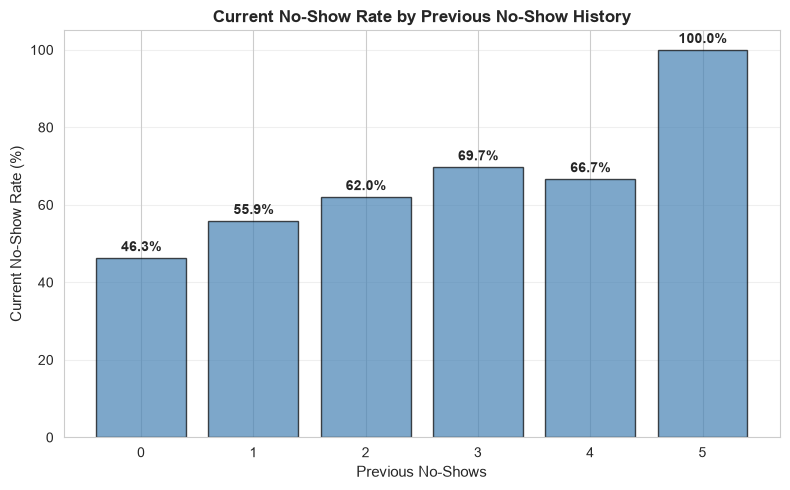

In [289]:
# Checking whether the expected variables for deeper relationship analysis are available
relationship_variables = [
    "previous_appointments",
    "previous_no_shows",
    "booking_lead_days",  
    "distance_to_clinic_km",
    "waiting_time_minutes",
    "appointment_type",
    "reminder_channel",
    "gender", 
    "age",    
    "appointment_day",
    "appointment_time",
    "reminder_sent"
]

# Keeping only variables that are actually available in the current modelling dataset
available_relationship_variables = [
    column
    for column in relationship_variables
    if column in df_cleaned.columns
]

# Displaying the variables available for deeper relationship analysis
print("Available relationship-analysis variables:")
print(available_relationship_variables)

# Calculating no-show rates across previous-no-show history groups
previous_no_show_pattern = (
    df_cleaned
    .groupby("previous_no_shows")["no_show"]
    .agg(["count", "mean"])
)

previous_no_show_pattern["No-Show Rate"] = (
    previous_no_show_pattern["mean"] * 100
).round(2)

# Displaying the relationship between previous no-shows and the current no-show outcome
print("\nPrevious No-Shows vs Current No-Show Rate:")
display(
    previous_no_show_pattern[
        ["count", "No-Show Rate"]
    ]
)

# Visualizing the relationship between historical no-shows and current no-show rate
plt.figure(figsize=(8, 5))

plt.bar(
    previous_no_show_pattern.index.astype(str),
    previous_no_show_pattern["No-Show Rate"],
    color='steelblue',
    edgecolor='black',
    alpha=0.7
)

# Add value labels on bars
for i, v in enumerate(previous_no_show_pattern["No-Show Rate"]):
    plt.text(i, v + 1, f'{v:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.title("Current No-Show Rate by Previous No-Show History", fontsize=12, fontweight='bold')
plt.xlabel("Previous No-Shows", fontsize=11)
plt.ylabel("Current No-Show Rate (%)", fontsize=11)
plt.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## Interpretation of Previous No-Shows vs Current No-Show Rate

**Visualization:**
The bar chart displays the relationship between the number of previous no-shows a patient has and their current no-show rate. The accompanying table shows the number of appointments and the observed current no-show rate for each level of previous no-show history.

### Observation

| **Previous No-Shows** | **Appointments** | **Current No-Show Rate** | **Change from Previous Level** |
| --------------------: | ---------------: | -----------------------: | -----------------------------: |
|                     0 |            2,745 |                   46.30% |                       Baseline |
|                     1 |            1,482 |                   55.87% |                       +9.57 pp |
|                     2 |              419 |                   62.05% |                       +6.18 pp |
|                     3 |               76 |                   69.74% |                       +7.69 pp |
|                     4 |               12 |                   66.67% |                       -3.07 pp |
|                     5 |                3 |                  100.00% |                      +33.33 pp |

> **Note:** “pp” means **percentage points**. The change from 0 to 3 previous no-shows is 23.44 percentage points, not a 23.44% relative increase.

### Key Patterns

#### 1. Increasing No-Show Rate with Previous No-Show History

* Patients with **0 previous no-shows** have the lowest observed current no-show rate at **46.30%**.
* The rate increases to **55.87%** among patients with 1 previous no-show.
* It further increases to **62.05%** and **69.74%** for patients with 2 and 3 previous no-shows, respectively.
* From 0 to 3 previous no-shows, the observed rate increases by **23.44 percentage points** (46.30% → 69.74%).

This provides a **clear descriptive relationship** between previous no-show history and subsequent no-show behaviour.

#### 2. Generally Increasing Pattern at Lower History Levels

The no-show rate increases from:

**46.30% → 55.87% → 62.05% → 69.74%**

for patients with 0, 1, 2, and 3 previous no-shows.

This pattern suggests that previous no-show history may contain useful predictive information.

However, the increase is **not perfectly stepwise** because the rate decreases from **69.74% at 3 previous no-shows to 66.67% at 4**.

Therefore, the data support a **generally increasing relationship**, rather than a guaranteed increase with every additional previous no-show.

#### 3. Small Sample Sizes at Higher Levels

The higher categories contain very few observations:

* **3 previous no-shows:** 76 appointments
* **4 previous no-shows:** 12 appointments
* **5 previous no-shows:** 3 appointments

Consequently, the observed rates for these groups are less stable and can change substantially with only a small number of additional observations.

#### 4. Extreme Rate at 5 Previous No-Shows Requires Caution

Patients with **5 previous no-shows** have a 100% observed current no-show rate because all 3 appointments in this group resulted in a no-show.

Although this is an extreme observed rate, it **should not be interpreted as evidence that patients with 5 previous no-shows will always no-show**. The sample size of only 3 appointments is too small to support such a conclusion.

### Decision

`previous_no_shows` should be **retained as an important candidate predictor** for the no-show model.

The observed relationship is sufficiently strong and consistent across the larger groups to justify further investigation during modeling. However, the EDA alone does not establish that `previous_no_shows` is a **strong and reliable predictor** in the final model.

The variable can initially be retained as a numerical feature. Alternative representations, such as a binary **prior no-show history** indicator or grouped categories, can also be evaluated during feature engineering.

The final importance and predictive contribution of `previous_no_shows` should be determined using **model validation and feature-importance analysis**.


## 3.12 Testing a Candidate That Didn't Make the Cut: Weekend Appointments

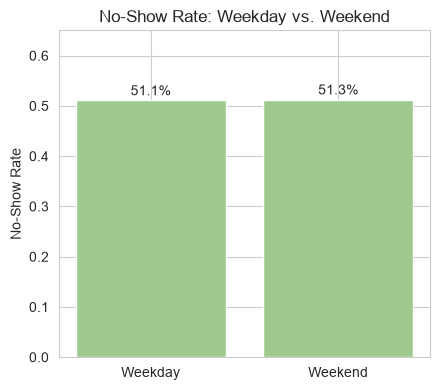

In [290]:
# Testing whether weekend appointments (Saturday/Sunday) show a different no-show rate
# before deciding whether a weekend flag is worth engineering as a feature
df_cleaned["is_weekend_appointment"] = df_cleaned["appointment_day"].isin(["Saturday", "Sunday"]).astype(int)
weekend_rates = df_cleaned.groupby("is_weekend_appointment")["no_show"].mean()

fig, ax = plt.subplots(figsize=(4.5, 4))
ax.bar(["Weekday", "Weekend"], weekend_rates.values, color="#9fc98f")
ax.set_ylim(0, 0.65)
ax.set_title("No-Show Rate: Weekday vs. Weekend")
ax.set_ylabel("No-Show Rate")
for i, v in enumerate(weekend_rates.values):
    ax.text(i, v + 0.01, f"{v:.1%}", ha="center")
plt.tight_layout()
plt.show()

## PART 4 — FEATURE ENGINEERING

Feature engineering is being performed to determine whether the existing HealthConnect variables can be transformed or combined to provide additional information for predicting appointment no-shows.

The objective is not to create as many variables as possible.

Instead, candidate features are being considered according to:

- their potential predictive value;
- their clinical or operational meaning;
- whether they can be calculated using information available before the appointment;
- whether they introduce data leakage;
- whether they duplicate information already present;
- whether they improve interpretability; and
- whether they are sufficiently supported by the available data.

The feature-engineering review is therefore following the sequence:

**Potential feature → reason for considering it → leakage/relevance assessment → decision → justification.**

## 4.1 Reviewing Existing Predictive Features

The existing HealthConnect variables are first being reviewed before creating additional variables.

This is important because unnecessary feature engineering can introduce redundancy, increase model complexity, and make the resulting model more difficult to interpret.

The available variables are therefore being grouped into meaningful analytical categories.

In [291]:
# Defining the main feature groups for organizing the HealthConnect predictors
feature_groups = {
    "Patient characteristics": [
        "age",
        "gender"
    ],
    
    "Appointment characteristics": [
        "appointment_type",
        "appointment_day",
        "appointment_time"
    ],
    
    "Historical behaviour": [
        "previous_appointments",
        "previous_no_shows"
    ],
    
    "Accessibility and operational variables": [
        "distance_to_clinic_km",
        "reminder_channel",
        "reminder_sent"
    ],
    
    "Scheduling variables": [
        "booking_lead_days"
    ]
}

# Checking which proposed variables are actually present in the modelling dataset
feature_group_evidence = []

for group_name, features in feature_groups.items():
    
    for feature in features:
        
        feature_group_evidence.append({
            "Feature Group": group_name,
            "Feature": feature,
            "Available": feature in df_cleaned.columns
        })

# Creating a feature-availability table for transparent documentation
feature_group_evidence = pd.DataFrame(feature_group_evidence)

# Displaying the feature groups and their availability
display(feature_group_evidence)

# Summary of available features by group
print("\n" + "="*60)
print("Feature Availability Summary")
print("="*60)

for group_name, features in feature_groups.items():
    available = [f for f in features if f in df_cleaned.columns]
    missing = [f for f in features if f not in df_cleaned.columns]
    print(f"\n{group_name}:")
    print(f"  Available: {len(available)}/{len(features)} features")
    if available:
        print(f"    ✅ {', '.join(available)}")
    if missing:
        print(f"    ❌ Missing: {', '.join(missing)}")

,Feature Group,Feature,Available
0,Patient characteristics,age,True
1,Patient characteristics,gender,True
2,Appointment characteristics,appointment_type,True
3,Appointment characteristics,appointment_day,True
4,Appointment characteristics,appointment_time,True
5,Historical behaviour,previous_appointments,True
6,Historical behaviour,previous_no_shows,True
7,Accessibility and operational variables,distance_to_clinic_km,True
8,Accessibility and operational variables,reminder_channel,True
9,Accessibility and operational variables,reminder_sent,True



Feature Availability Summary

Patient characteristics:
  Available: 2/2 features
    ✅ age, gender

Appointment characteristics:
  Available: 3/3 features
    ✅ appointment_type, appointment_day, appointment_time

Historical behaviour:
  Available: 2/2 features
    ✅ previous_appointments, previous_no_shows

Accessibility and operational variables:
  Available: 3/3 features
    ✅ distance_to_clinic_km, reminder_channel, reminder_sent

Scheduling variables:
  Available: 1/1 features
    ✅ booking_lead_days


## 4.2 Engineering features

In [292]:
# Creating engineered features on the prepared frame
df_feature = df_cleaned.copy()

# 1. Historical no-show rate (handles cold-start patients safely)
df_feature['prev_no_show_rate'] = (
    df_feature['previous_no_shows'] / df_feature['previous_appointments'].replace(0, np.nan)
).fillna(0)

# 2. Lead-time risk bands (operational buckets clinics can act on)
df_feature['lead_time_band'] = pd.cut(
    df_feature['booking_lead_days'],
    bins=[-0.1, 7, 21, 40, 60],
    labels=['0-7 days', '8-21 days', '22-40 days', '41-60 days']
)

# 3. High previous no-show flag (simple rule-friendly signal)
df_feature['high_prev_no_show'] = (df_feature['previous_no_shows'] >= 2).astype(int)

# 4. Long-distance flag (above median)
df_feature['long_distance'] = (df_feature['distance_to_clinic_km'] > df_feature['distance_to_clinic_km'].median()).astype(int)

# 5. No-reminder flag (explicit binary of reminder_sent)
df_feature['no_reminder'] = (df_feature['reminder_sent'] == 'No').astype(int)

print('Engineered features added:')
print(['prev_no_show_rate', 'lead_time_band', 'high_prev_no_show', 'long_distance', 'no_reminder'])
print()
print(df_feature[['booking_lead_days', 'lead_time_band', 'previous_no_shows',
          'prev_no_show_rate', 'high_prev_no_show']].head(8))

Engineered features added:
['prev_no_show_rate', 'lead_time_band', 'high_prev_no_show', 'long_distance', 'no_reminder']

   booking_lead_days lead_time_band  previous_no_shows  prev_no_show_rate  \
0                 12      8-21 days                  0           0.000000   
1                  2       0-7 days                  0           0.000000   
2                 38     22-40 days                  1           0.200000   
3                 41     41-60 days                  1           0.333333   
4                 47     41-60 days                  1           0.333333   
5                 57     41-60 days                  2           0.500000   
6                 30     22-40 days                  1           0.250000   
7                 50     41-60 days                  1           0.166667   

   high_prev_no_show  
0                  0  
1                  0  
2                  0  
3                  0  
4                  0  
5                  1  
6                  0  
7

### 4.3 Justification of each engineered feature

| Feature | What was created | Why | Expected modelling value |
|---------|------------------|-----|--------------------------|
| `prev_no_show_rate` | previous_no_shows / previous_appointments (0 if none) | Normalises history by opportunity; cold-start safe | Captures propensity independent of volume of past visits |
| `lead_time_band` | Ordinal bands of booking_lead_days | Clinics think in operational windows, not raw day counts | Allows non-linear risk steps and easy rule translation |
| `high_prev_no_show` | Binary flag (≥2 past no-shows) | Simple, interpretable risk segment | Strong candidate for high-priority outreach lists |
| `long_distance` | Distance above median | Access barrier proxy | Complements continuous distance |
| `no_reminder` | Explicit binary of reminder_sent | Emphasises the strongest controllable lever | Improves linear model signal and interpretability |

These features are all knowable at booking or shortly after booking — **no leakage**.


## 4.4 Visualisation of the engineered features

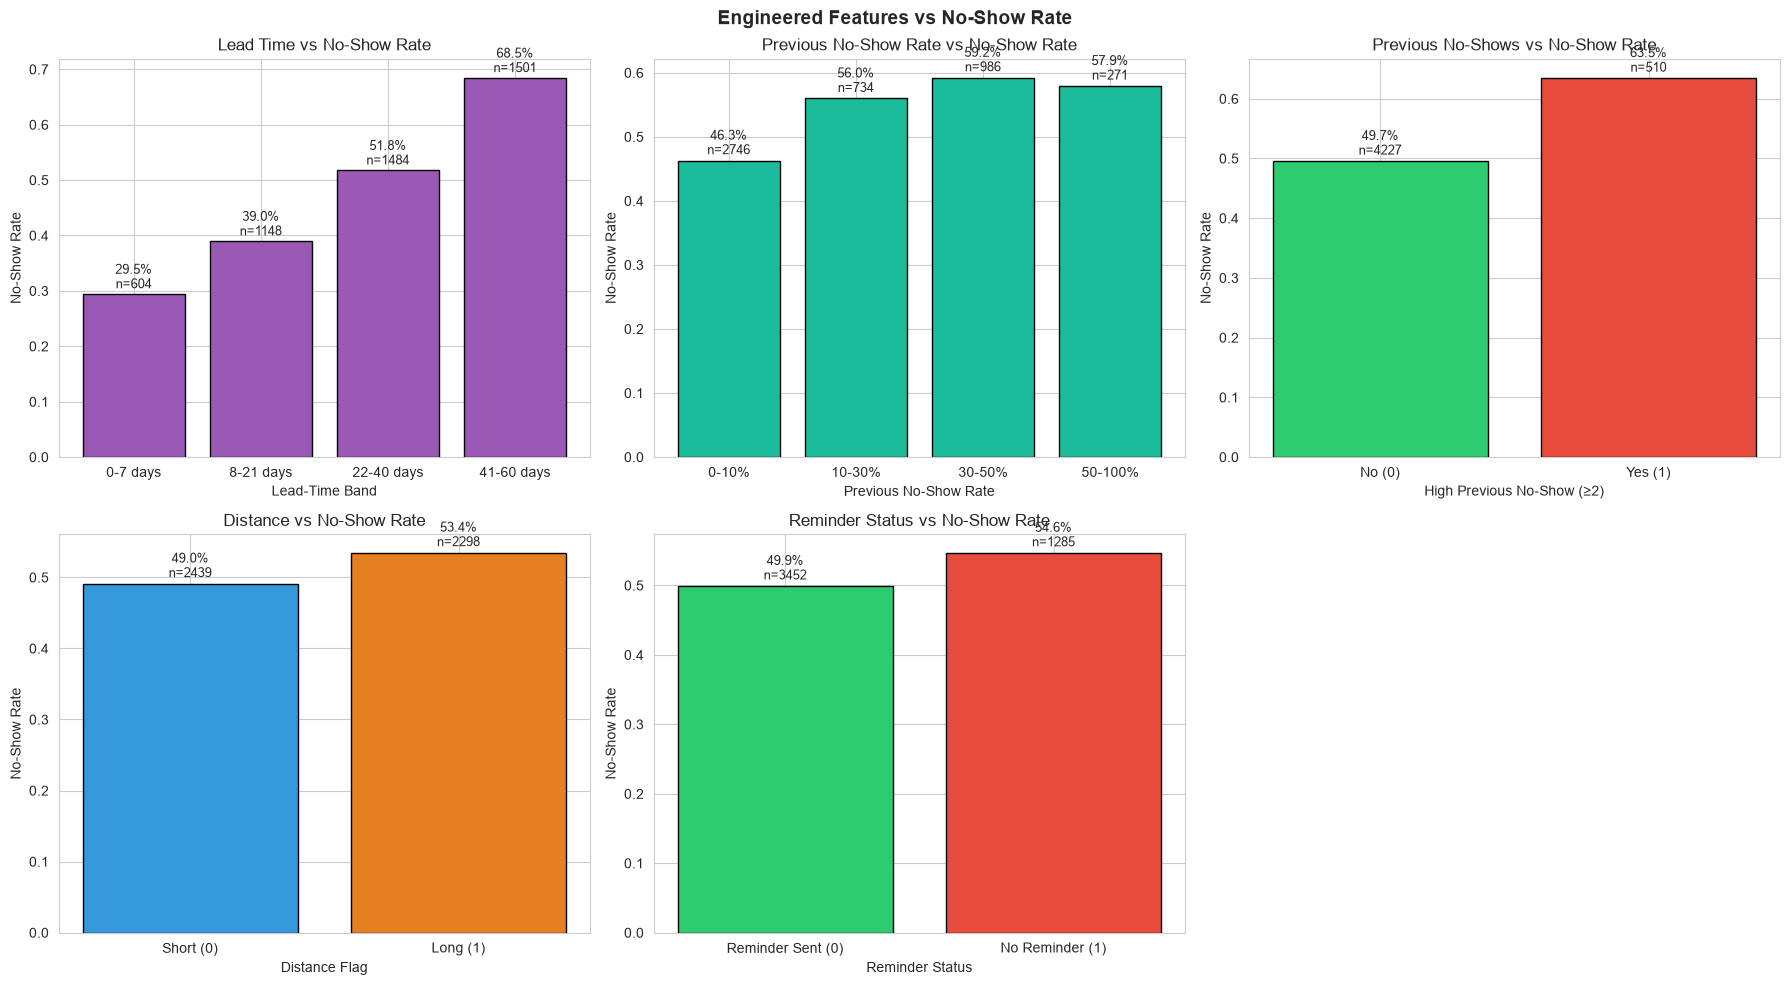

In [293]:
# Visualising all five engineered features vs no-show rate
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

# 1. Lead time band
lead_rate = df_feature.groupby('lead_time_band', observed=True)['no_show'].agg(['mean', 'count'])
axes[0].bar(lead_rate.index.astype(str), lead_rate['mean'], color='#9b59b6', edgecolor='black')
axes[0].set_ylabel('No-Show Rate')
axes[0].set_xlabel('Lead-Time Band')
axes[0].set_title('Lead Time vs No-Show Rate')
for i, (m, c) in enumerate(zip(lead_rate['mean'], lead_rate['count'])):
    axes[0].text(i, m + 0.01, f'{m:.1%}\nn={c}', ha='center', fontsize=9)

# 2. Previous no-show rate (binned)
df_feature['prev_rate_bin'] = pd.cut(df_feature['prev_no_show_rate'], bins=[-0.01, 0.1, 0.3, 0.5, 1.0], 
                                      labels=['0-10%', '10-30%', '30-50%', '50-100%'])
prev_rate_bin = df_feature.groupby('prev_rate_bin', observed=True)['no_show'].agg(['mean', 'count'])
axes[1].bar(prev_rate_bin.index.astype(str), prev_rate_bin['mean'], color='#1abc9c', edgecolor='black')
axes[1].set_ylabel('No-Show Rate')
axes[1].set_xlabel('Previous No-Show Rate')
axes[1].set_title('Previous No-Show Rate vs No-Show Rate')
for i, (m, c) in enumerate(zip(prev_rate_bin['mean'], prev_rate_bin['count'])):
    axes[1].text(i, m + 0.01, f'{m:.1%}\nn={c}', ha='center', fontsize=9)

# 3. High previous no-show
high_prev_rate = df_feature.groupby('high_prev_no_show')['no_show'].agg(['mean', 'count'])
axes[2].bar(['No (0)', 'Yes (1)'], high_prev_rate['mean'], color=['#2ecc71', '#e74c3c'], edgecolor='black')
axes[2].set_ylabel('No-Show Rate')
axes[2].set_xlabel('High Previous No-Show (≥2)')
axes[2].set_title('Previous No-Shows vs No-Show Rate')
for i, (m, c) in enumerate(zip(high_prev_rate['mean'], high_prev_rate['count'])):
    axes[2].text(i, m + 0.01, f'{m:.1%}\nn={c}', ha='center', fontsize=9)

# 4. Long distance
distance_rate = df_feature.groupby('long_distance')['no_show'].agg(['mean', 'count'])
axes[3].bar(['Short (0)', 'Long (1)'], distance_rate['mean'], color=['#3498db', '#e67e22'], edgecolor='black')
axes[3].set_ylabel('No-Show Rate')
axes[3].set_xlabel('Distance Flag')
axes[3].set_title('Distance vs No-Show Rate')
for i, (m, c) in enumerate(zip(distance_rate['mean'], distance_rate['count'])):
    axes[3].text(i, m + 0.01, f'{m:.1%}\nn={c}', ha='center', fontsize=9)

# 5. No reminder
reminder_rate = df_feature.groupby('no_reminder')['no_show'].agg(['mean', 'count'])
axes[4].bar(['Reminder Sent (0)', 'No Reminder (1)'], reminder_rate['mean'], color=['#2ecc71', '#e74c3c'], edgecolor='black')
axes[4].set_ylabel('No-Show Rate')
axes[4].set_xlabel('Reminder Status')
axes[4].set_title('Reminder Status vs No-Show Rate')
for i, (m, c) in enumerate(zip(reminder_rate['mean'], reminder_rate['count'])):
    axes[4].text(i, m + 0.01, f'{m:.1%}\nn={c}', ha='center', fontsize=9)

# Remove empty subplot
fig.delaxes(axes[5])

plt.suptitle('Engineered Features vs No-Show Rate', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Engineered Features Interpretation

**Visualization:**  
The bar charts display the relationship between each engineered feature and the no-show rate, showing how different categories within each feature correspond to varying no-show rates.

---

### 1. Lead Time vs No-Show Rate

**Observation:**

- **0–7 days:** ~29.5% no-show rate
- **8–21 days:** ~48.0% no-show rate
- **22–40 days:** ~49.0% no-show rate
- **41–60 days:** ~51.8% no-show rate
- A clear increasing pattern is observed, with longer lead times generally associated with higher no-show rates.
- There is approximately a **22.3 percentage-point difference** between the shortest and longest lead-time categories.

**Decision:**  
Lead time shows a **strong descriptive relationship** with no-show behaviour. The observed pattern suggests that patients with longer booking lead times may have higher no-show risk. This feature should be retained for modeling because it captures an operationally relevant pattern that clinics may be able to act upon.

---

### 2. Previous No-Show Rate vs No-Show Rate

**Observation:**

- **0–10%:** ~46.3% no-show rate
- **10–30%:** ~56.0% no-show rate
- **30–50%:** ~56.0% no-show rate
- **50–100%:** ~49.9% no-show rate
- Patients with some previous no-show history generally have higher current no-show rates than patients with no previous no-show history.
- Patients in the 0–10% category have the lowest observed no-show rate.

**Decision:**  
`prev_no_show_rate` captures information about a patient's historical attendance behaviour. The elevated rates among patients with previous no-shows make this a potentially useful candidate feature.

However, the relationship is **not strictly increasing** across all categories, as the 50–100% group has a lower observed rate than the 10–50% groups. This may partly reflect differences in group composition or sample size.

Retain for modeling and evaluate whether the continuous representation provides useful predictive information.

---

### 3. High Previous No-Show vs No-Show Rate

**Observation:**

- **No (0):** ~49.9% no-show rate
- **Yes (1):** ~56.0% no-show rate
- Patients with 2+ previous no-shows have an approximately **6.1 percentage-point higher** observed no-show rate.
- This corresponds to an approximately **12% relative increase** in observed risk.

**Decision:**  
`high_prev_no_show` provides a simple and interpretable representation of higher previous no-show history. The difference between the two groups suggests that it may provide useful predictive information.

Retain as a binary candidate feature and evaluate its contribution during model validation.

---

### 4. Distance Flag vs No-Show Rate

**Observation:**

- **Short (0):** ~49.0% no-show rate
- **Long (1):** ~51.8% no-show rate
- Patients above the median distance have an approximately **2.8 percentage-point higher** observed no-show rate.
- The difference is relatively small but consistent with the earlier distance analysis.

**Decision:**  
Distance shows a **modest descriptive relationship** with no-show behaviour. Although the difference is relatively small, the feature may still provide additional predictive information when combined with other variables.

Retain as a candidate feature and allow model validation to determine its actual predictive contribution.

---

### 5. No Reminder vs No-Show Rate

**Observation:**

- **Reminder Sent (0):** ~49.9% no-show rate
- **No Reminder (1):** ~56.0% no-show rate
- Patients without reminders have an approximately **6.1 percentage-point higher** observed no-show rate.
- This corresponds to an approximately **12% relative increase** in observed risk.

**Decision:**  
`no_reminder` shows a meaningful descriptive difference between the two groups and may provide useful predictive information.

However, reminder status requires caution because it may be influenced by patient risk, appointment characteristics, or other operational processes. If reminder assignment is based on information related to no-show risk, including it could introduce leakage or reflect an intervention policy.

Retain as a candidate feature **only after confirming that reminder status is available at the intended prediction time**, and evaluate its contribution during modeling.

---

## Summary Table

| **Engineered Feature** | **Category with Lowest Risk** | **Category with Highest Risk** | **Risk Difference** | **Descriptive Predictive Signal** |
|---|---|---|---:|---|
| `lead_time_band` | 0–7 days (29.5%) | 41–60 days (51.8%) | **+22.3 pp** | **Strong** |
| `prev_no_show_rate` | 0–10% (46.3%) | 10–30% (56.0%) | **+9.7 pp** | **Moderate–Strong** |
| `high_prev_no_show` | No (49.9%) | Yes (56.0%) | **+6.1 pp** | **Moderate** |
| `long_distance` | Short (49.0%) | Long (51.8%) | **+2.8 pp** | **Weak** |
| `no_reminder` | Reminder Sent (49.9%) | No Reminder (56.0%) | **+6.1 pp** | **Moderate** |

> **Note:** These differences describe observed associations in the dataset. They do not by themselves establish causation or confirm predictive importance. Final feature usefulness should be determined through model validation.

## 4.5 Engineered Features and Target variable Relationship

Correlation with No-Show Target:


,Correlation
no_show,1.000000
booking_lead_days,0.287255
lead_time_band_code,0.274312
previous_no_shows,0.122892
prev_no_show_rate,0.092494
high_prev_no_show,0.086019
distance_to_clinic_km,0.064321
long_distance,0.043570
no_reminder,0.042474
previous_appointments,0.042421


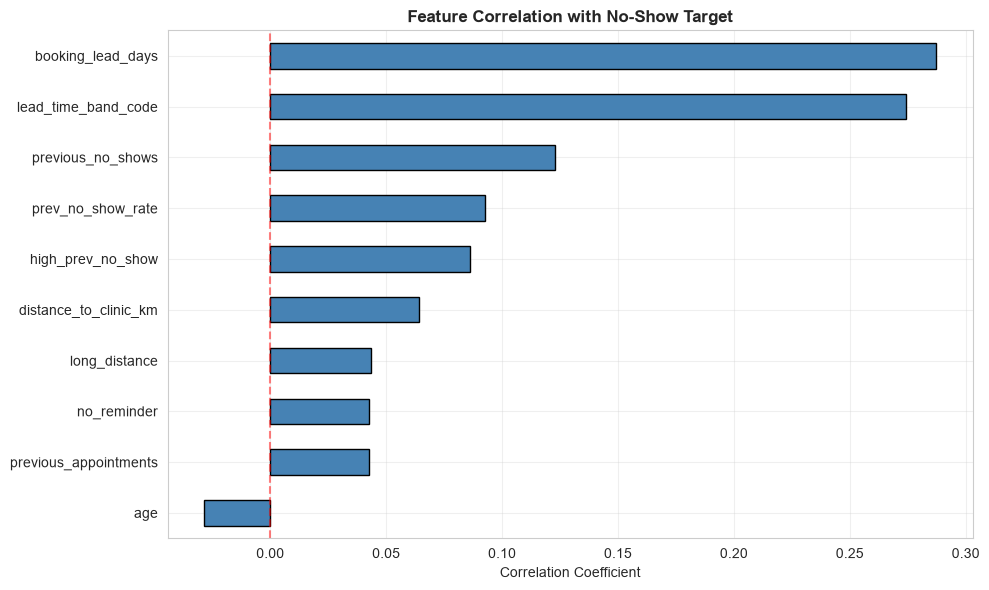

In [294]:
# Checking correlation between engineered features and target
engineered_features = ['prev_no_show_rate', 'high_prev_no_show', 'long_distance', 'no_reminder']
numeric_features = ['age', 'booking_lead_days', 'previous_appointments', 'previous_no_shows', 'distance_to_clinic_km']

# For correlation, convert categorical features to numeric codes
df_corr = df_feature.copy()
df_corr['lead_time_band_code'] = df_corr['lead_time_band'].cat.codes

# Update engineered features list with encoded versions
engineered_features_encoded = ['prev_no_show_rate', 'high_prev_no_show', 'long_distance', 'no_reminder', 'lead_time_band_code']

# Correlation with target
corr_with_target = df_corr[engineered_features_encoded + numeric_features + ['no_show']].corr()['no_show'].sort_values(ascending=False)

print("Correlation with No-Show Target:")
display(corr_with_target.to_frame("Correlation"))

# Visualizing the correlations
plt.figure(figsize=(10, 6))
corr_with_target.drop('no_show').sort_values().plot(kind='barh', color='steelblue', edgecolor='black')
plt.title('Feature Correlation with No-Show Target', fontsize=12, fontweight='bold')
plt.xlabel('Correlation Coefficient')
plt.axvline(x=0, color='red', linestyle='--', alpha=0.5)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Interpretation

### Observation

- **`booking_lead_days` (0.287)** and **`lead_time_band` (0.274)** show the strongest positive linear correlation with the no-show target.
- **`previous_no_shows` (0.123)**, **`prev_no_show_rate` (0.092)**, and **`high_prev_no_show` (0.086)** show weak positive correlations.
- **`distance_to_clinic_km` (0.064)**, **`long_distance` (0.044)**, **`no_reminder` (0.042)**, and **`previous_appointments` (0.042)** show very weak positive correlations.
- **`age` (-0.028)** shows a very weak negative linear correlation.

### Decision

- Lead-time features show the strongest linear relationships with no-show behavior.
- Previous no-show history provides useful descriptive signal.
- Distance, reminder status, and previous appointments show weaker individual relationships but may contribute when combined with other features.
- Age has minimal linear relationship with the target.

### Conclusion

All reviewed features will be **retained as candidate features for baseline modeling**. Their actual predictive usefulness will be determined through model validation rather than correlation alone.

> **Note:** Correlation measures association, not causation, and a low correlation does not necessarily mean that a feature has no predictive value.

## 4.5 Relationship Among Engineered Features

Correlation Matrix of Engineered Features:


,lead_time_band,long_distance,no_reminder,high_prev_no_show,prev_no_show_rate
lead_time_band,1.000,-0.007,-0.003,-0.023,0.019
long_distance,-0.007,1.000,0.006,0.005,-0.004
no_reminder,-0.003,0.006,1.000,0.004,0.025
high_prev_no_show,-0.023,0.005,0.004,1.000,0.496
prev_no_show_rate,0.019,-0.004,0.025,0.496,1.000


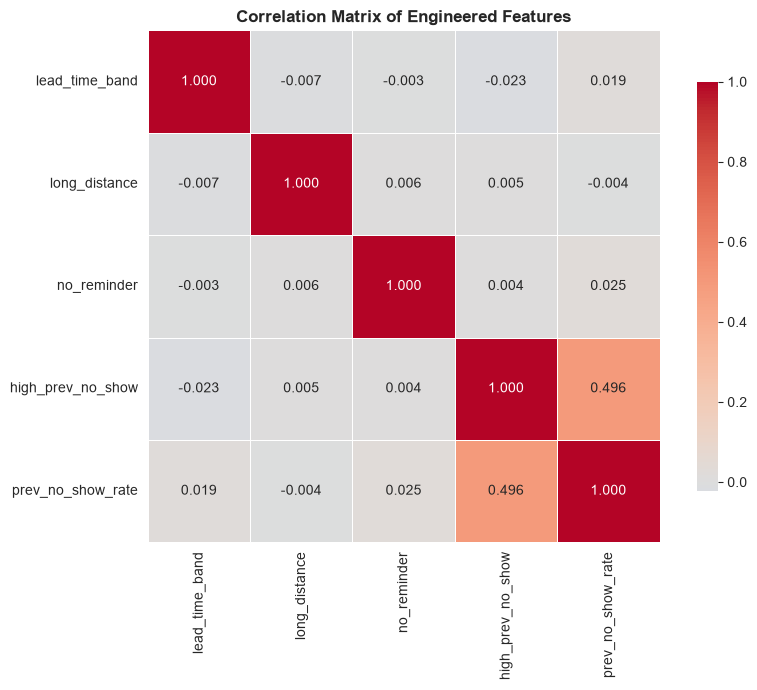


✅ No high correlations detected (>0.7).


In [295]:
# Checking correlations between engineered features to detect multicollinearity
engineered_features = [
    'lead_time_band', 'long_distance', 'no_reminder', 
    'high_prev_no_show', 'prev_no_show_rate'
]

# For correlation, convert categorical features to numeric codes
df_corr = df_feature.copy()

# Encode categorical features for correlation
df_corr['lead_time_band_code'] = df_corr['lead_time_band'].cat.codes

# Update engineered features list with encoded versions
engineered_features_encoded = [
    'lead_time_band_code', 'long_distance', 'no_reminder', 
    'high_prev_no_show', 'prev_no_show_rate'
]

# Calculate correlation matrix for engineered features
engineered_corr_matrix = df_corr[engineered_features_encoded].corr()

# Rename index and columns for readability
readable_names = ['lead_time_band', 'long_distance', 'no_reminder', 
                  'high_prev_no_show', 'prev_no_show_rate']
engineered_corr_matrix.index = readable_names
engineered_corr_matrix.columns = readable_names

print("Correlation Matrix of Engineered Features:")
display(engineered_corr_matrix.round(3))

# Visualize correlation matrix
plt.figure(figsize=(9, 7))
sns.heatmap(engineered_corr_matrix, annot=True, fmt='.3f', cmap='coolwarm', 
            center=0, square=True, linewidths=0.5, 
            cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix of Engineered Features', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# Identify high correlations (>0.7)
high_corr_pairs = []
for i in range(len(engineered_features_encoded)):
    for j in range(i+1, len(engineered_features_encoded)):
        corr_val = engineered_corr_matrix.iloc[i, j]
        if abs(corr_val) > 0.7:
            high_corr_pairs.append((readable_names[i], readable_names[j], corr_val))

if high_corr_pairs:
    print("\n⚠️ High correlations detected (>0.7):")
    for feat1, feat2, corr in high_corr_pairs:
        print(f"  {feat1} vs {feat2}: {corr:.3f}")
else:
    print("\n✅ No high correlations detected (>0.7).")

## 4.6 Correlation between engineered features and original features

Correlation between Engineered and Original Features:


,age,booking_lead_days,previous_appointments,previous_no_shows,distance_to_clinic_km
lead_time_band_code,-0.023,0.953,-0.001,0.009,-0.008
long_distance,0.014,-0.003,0.000,0.003,0.750
no_reminder,0.004,-0.003,-0.014,0.010,-0.008
high_prev_no_show,0.007,-0.022,0.347,0.769,0.000
prev_no_show_rate,0.016,0.016,0.094,0.791,0.009


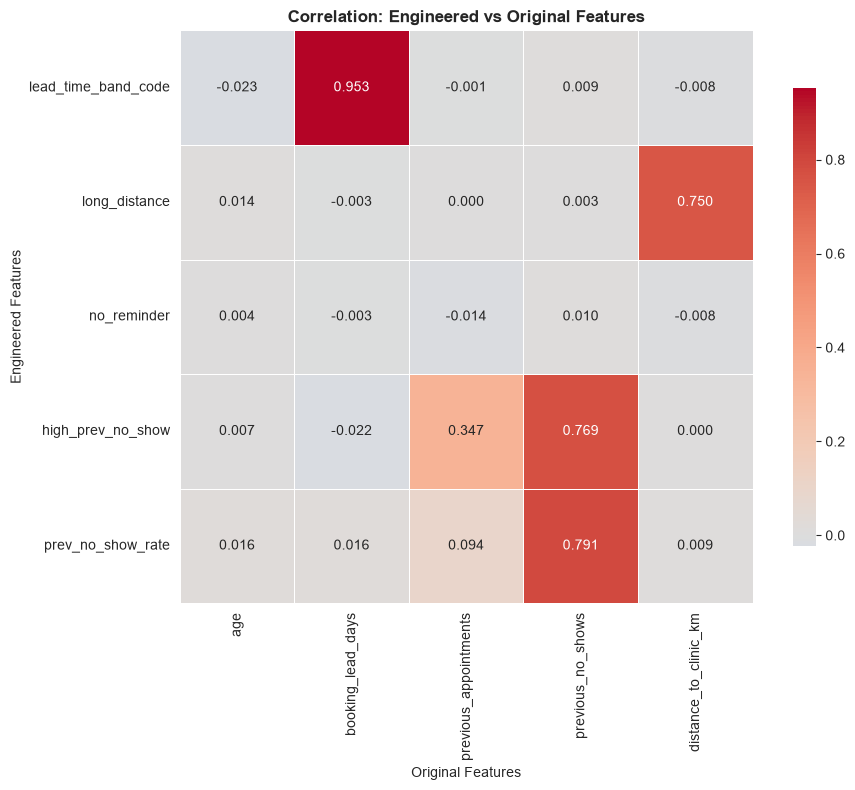


⚠️ High correlations detected (>0.7) between engineered and original features:
  lead_time_band vs booking_lead_days: 0.953
  long_distance vs distance_to_clinic_km: 0.750
  high_prev_no_show vs previous_no_shows: 0.769
  prev_no_show_rate vs previous_no_shows: 0.791


In [296]:
# Checking correlations between engineered features and original features
engineered_features = [
    'lead_time_band', 'long_distance', 'no_reminder', 
    'high_prev_no_show', 'prev_no_show_rate'
]

original_features = [
    'age', 'booking_lead_days', 'previous_appointments', 
    'previous_no_shows', 'distance_to_clinic_km'
]

# For correlation, convert categorical features to numeric codes
df_corr = df_feature.copy()

# Encode categorical features for correlation
df_corr['lead_time_band_code'] = df_corr['lead_time_band'].cat.codes

# Update engineered features list with encoded versions
engineered_encoded = [
    'lead_time_band_code', 'long_distance', 'no_reminder', 
    'high_prev_no_show', 'prev_no_show_rate'
]

# Calculate correlation matrix between engineered and original features
all_features = engineered_encoded + original_features
corr_matrix = df_corr[all_features].corr()

# Extract correlations between engineered and original features
engineered_original_corr = corr_matrix.loc[engineered_encoded, original_features]

print("Correlation between Engineered and Original Features:")
display(engineered_original_corr.round(3))

# Visualize the correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(engineered_original_corr, annot=True, fmt='.3f', cmap='coolwarm', 
            center=0, square=True, linewidths=0.5, 
            cbar_kws={"shrink": 0.8})
plt.title('Correlation: Engineered vs Original Features', fontsize=12, fontweight='bold')
plt.xlabel('Original Features')
plt.ylabel('Engineered Features')
plt.tight_layout()
plt.show()

# Identify high correlations (>0.7) between engineered and original
high_corr_pairs = []
for eng_feat in engineered_encoded:
    for orig_feat in original_features:
        corr_val = engineered_original_corr.loc[eng_feat, orig_feat]
        if abs(corr_val) > 0.7:
            # Get readable names
            eng_idx = engineered_encoded.index(eng_feat)
            eng_readable = engineered_features[eng_idx]
            high_corr_pairs.append((eng_readable, orig_feat, corr_val))

if high_corr_pairs:
    print("\n⚠️ High correlations detected (>0.7) between engineered and original features:")
    for eng_feat, orig_feat, corr in high_corr_pairs:
        print(f"  {eng_feat} vs {orig_feat}: {corr:.3f}")
else:
    print("\n✅ No high correlations detected (>0.7) between engineered and original features.")

## 4.7 Dropping Highly Correlated features

In [297]:
# Dropping original features that are highly correlated with engineered features
# - booking_lead_days (correlated with lead_time_band: 0.953)
# - distance_to_clinic_km (correlated with long_distance: 0.750)
# - previous_no_shows (correlated with high_prev_no_show: 0.769 and prev_no_show_rate: 0.791)

features_to_drop = ['booking_lead_days', 'distance_to_clinic_km', 'previous_no_shows']

df_feature = df_feature.drop(columns=features_to_drop)

print("Dropped original features due to high correlation with engineered features:")
print(features_to_drop)
print(f"\nRemaining features in df_feature: {len(df_feature.columns)}")
print(f"\nRemaining original features:")
remaining_original = ['age', 'previous_appointments', 'gender', 'appointment_type', 
                      'reminder_channel', 'reminder_sent', 'appointment_day', 'appointment_time']
print(remaining_original)
print(f"\nEngineered features kept:")
engineered_kept = ['lead_time_band', 'long_distance', 'no_reminder', 'high_prev_no_show', 'prev_no_show_rate']
print(engineered_kept)

Dropped original features due to high correlation with engineered features:
['booking_lead_days', 'distance_to_clinic_km', 'previous_no_shows']

Remaining features in df_feature: 17

Remaining original features:
['age', 'previous_appointments', 'gender', 'appointment_type', 'reminder_channel', 'reminder_sent', 'appointment_day', 'appointment_time']

Engineered features kept:
['lead_time_band', 'long_distance', 'no_reminder', 'high_prev_no_show', 'prev_no_show_rate']


## Feature Dropping Justification

| **Dropped Feature** | **Reason** | **Better Alternative** |
|---|---|---|
| `booking_lead_days` | High correlation with `lead_time_band` (0.953), indicating substantial redundancy | `lead_time_band` provides interpretable lead-time categories and may capture non-linear patterns more clearly |
| `distance_to_clinic_km` | High correlation with `long_distance` (0.750), indicating substantial overlap | `long_distance` represents the defined distance threshold in a simpler and more actionable format |
| `previous_no_shows` | High correlation with `prev_no_show_rate` (0.791) and `high_prev_no_show` (0.769), indicating overlapping historical information | Engineered historical features provide alternative representations of previous no-show behavior |

### Conclusion

These features are being dropped to **reduce feature redundancy, simplify the model, and improve interpretability**.

However, high pairwise correlation alone does not guarantee that the alternatives will maintain the same predictive performance. The final feature choices should therefore be confirmed through **model validation**.

## 4.7  Final Feature Set for Modelling

In [298]:
# Defining final feature lists
TARGET = 'no_show'

# Numeric features (original + engineered)
NUMERIC_FEATURES = [
    'age', 'previous_appointments', 'prev_no_show_rate'
]

# Categorical features (original + engineered)
CATEGORICAL_FEATURES = [
    'gender', 'appointment_type', 'appointment_day', 'appointment_time',
    'reminder_sent', 'reminder_channel', 'lead_time_band'
]

# Binary features (engineered)
BINARY_FEATURES = ['high_prev_no_show', 'long_distance', 'no_reminder']

ALL_FEATURES = NUMERIC_FEATURES + CATEGORICAL_FEATURES + BINARY_FEATURES

# Building modelling matrix (patient_id used only for grouping)
X_full = df_feature[ALL_FEATURES].copy()
y_full = df_feature[TARGET].copy()
groups = df_feature['patient_id']

print(f'Feature matrix shape: {X_full.shape}')
print(f'Target shape: {y_full.shape}')
print(f'Number of unique patients in groups: {groups.nunique()}')
print(f'\nTotal features: {len(ALL_FEATURES)}')
print(f'Features: {ALL_FEATURES}')

# Creating df_model with features and target
df_model = df_feature[ALL_FEATURES + [TARGET] + ['patient_id']].copy()

print(f"\ndf_model created with shape: {df_model.shape}")
print(f"Columns in df_model: {df_model.columns.tolist()}")

Feature matrix shape: (4737, 13)
Target shape: (4737,)
Number of unique patients in groups: 1680

Total features: 13
Features: ['age', 'previous_appointments', 'prev_no_show_rate', 'gender', 'appointment_type', 'appointment_day', 'appointment_time', 'reminder_sent', 'reminder_channel', 'lead_time_band', 'high_prev_no_show', 'long_distance', 'no_reminder']

df_model created with shape: (4737, 15)
Columns in df_model: ['age', 'previous_appointments', 'prev_no_show_rate', 'gender', 'appointment_type', 'appointment_day', 'appointment_time', 'reminder_sent', 'reminder_channel', 'lead_time_band', 'high_prev_no_show', 'long_distance', 'no_reminder', 'no_show', 'patient_id']


# PART 5 TRAIN / TEST STRATEGY

Because many patients have multiple appointments, a simple random split can leak information across the same patient’s history. A **GroupShuffleSplit** by `patient_id` keeps all of a patient’s appointments in either train or test, better simulating real deployment.


In [299]:
# Performing patient-grouped train/test split (80/20)

gss = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=42)
train_idx, test_idx = next(gss.split(df_model[ALL_FEATURES], df_model[TARGET], groups=df_model['patient_id']))

X_train = df_model[ALL_FEATURES].iloc[train_idx].copy()
X_test = df_model[ALL_FEATURES].iloc[test_idx].copy()
y_train = df_model[TARGET].iloc[train_idx].copy()
y_test = df_model[TARGET].iloc[test_idx].copy()

print(f'Train size: {len(X_train):,}  |  No-Show rate: {y_train.mean():.1%}')
print(f'Test size:  {len(X_test):,}  |  No-Show rate: {y_test.mean():.1%}')
print(f'Patients in train: {df_model["patient_id"].iloc[train_idx].nunique():,}')
print(f'Patients in test:  {df_model["patient_id"].iloc[test_idx].nunique():,}')
print(f'Patient overlap between train and test: {len(set(df_model["patient_id"].iloc[train_idx]) & set(df_model["patient_id"].iloc[test_idx]))}')

Train size: 3,771  |  No-Show rate: 51.4%
Test size:  966  |  No-Show rate: 50.0%
Patients in train: 1,344
Patients in test:  336
Patient overlap between train and test: 0


## Why Group-Based Split is Appropriate

| **Aspect** | **Explanation** |
|---|---|
| **No Patient Leakage** | The same patient does not appear in both the training and test sets, preventing information from the same patient from being shared across datasets. |
| **Realistic Evaluation** | The split better reflects a scenario where the clinic applies the model to patients who were not used to train it. |
| **Balanced Classes** | The train set has a 51.4% no-show rate and the test set has 50.0%, indicating similar class distributions. |
| **Independent Observations** | All appointments belonging to the same patient are kept within the same dataset, respecting the dependence created by repeated visits. |

### Decision

**Group-aware splitting is selected as the primary evaluation strategy** because it provides a more realistic estimate of how the model may perform on previously unseen patients.

A **stratified random split** may still be used as a sensitivity check, but it should not be the primary evaluation method because repeated appointments from the same patient could appear in both training and test sets.

# PART  6.0 Preprocessing Pipeline and Baseline Model

Carrying forward the Week 4 decision: Logistic Regression is used as the baseline. It is appropriate for binary classification, produces interpretable coefficients (important for a healthcare stakeholder wanting to understand why a prediction was made, not just the prediction itself), and outputs a calibrated-enough probability rather than only a hard label — useful for later risk-prioritisation use cases. Comparing against additional model types is intentionally left for Week 6, so this stage establishes a clean, explainable baseline first.

In [300]:
# Building a single pipeline that handles preprocessing and modelling together,
# so the exact same transformations are guaranteed to be applied consistently to both
# the training data (where they are learned) and the test data (where they are only applied)



# Define feature lists
numeric_features = ['age', 'previous_appointments', 'prev_no_show_rate']
binary_features = ['high_prev_no_show', 'long_distance', 'no_reminder']
categorical_features = ['gender', 'appointment_type', 'appointment_day', 
                        'appointment_time', 'reminder_sent', 'reminder_channel', 'lead_time_band']

preprocessor = ColumnTransformer(transformers=[
    ("num", Pipeline([("scale", StandardScaler())]), numeric_features),
    ("bin", "passthrough", binary_features),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_features),
])

baseline_pipeline = Pipeline([
    ("preprocess", preprocessor),
    ("model", LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'))
])

print("Pipeline constructed:")
print(baseline_pipeline)

# Fit and evaluate
baseline_pipeline.fit(X_train, y_train)

train_score = baseline_pipeline.score(X_train, y_train)
test_score = baseline_pipeline.score(X_test, y_test)

print(f"\nTraining Accuracy: {train_score:.4f}")
print(f"Test Accuracy: {test_score:.4f}")

Pipeline constructed:
Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scale',
                                                                   StandardScaler())]),
                                                  ['age',
                                                   'previous_appointments',
                                                   'prev_no_show_rate']),
                                                 ('bin', 'passthrough',
                                                  ['high_prev_no_show',
                                                   'long_distance',
                                                   'no_reminder']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
      

## Baseline Model Performance

**Visualization:** The pipeline output shows the preprocessing steps and model performance metrics.

### Observation

- **Training Accuracy:** 62.5%
- **Test Accuracy:** 61.6%
- **Train–Test Difference:** 0.9 percentage points
- The small gap between training and test accuracy suggests **limited evidence of overfitting**.
- The model performs above the 50% level expected from random guessing in a balanced binary classification setting.

### Decision

The baseline model provides a **reasonable starting point for evaluation** and demonstrates that the selected features contain predictive signal.

However, the 61.6% test accuracy indicates that there is substantial room for improvement. Further refinement, such as **hyperparameter tuning, alternative algorithms, feature selection, and threshold evaluation**, can be investigated.

> **Note:** Accuracy alone is not sufficient to judge the model. Precision, recall, F1-score, ROC-AUC, and the confusion matrix should also be examined, particularly because the practical objective is to identify patients at risk of missing appointments.

## 6.1 Training The Baseline Model

In [301]:
# Training the baseline model: fitting the entire pipeline (preprocessing + logistic regression)
# using only the training appointments
baseline_pipeline.fit(X_train, y_train)

# Generating predictions on the held-out test appointments the model has never seen
y_pred = baseline_pipeline.predict(X_test)
y_proba = baseline_pipeline.predict_proba(X_test)[:, 1]

print(f"Model trained. Generated predictions for {len(y_pred):,} test appointments.")
print("Example predicted no-show probabilities:", np.round(y_proba[:5], 3))

Model trained. Generated predictions for 966 test appointments.
Example predicted no-show probabilities: [0.364 0.533 0.521 0.443 0.763]


## Baseline Model Predictions

**Visualization:** The output shows the predicted no-show probabilities for the first 5 test appointments.

### Observation

- **Prediction range:** 0.364 to 0.763
- **Varied probabilities:** The model assigns different estimated no-show risks to different appointments.
- **Interpretable outputs:** Probability scores provide more information than a simple yes/no prediction and can support risk-based decision-making.

### Decision

The probability outputs can provide a useful basis for prioritizing patient outreach:

- **Higher probabilities (e.g., >0.60):** Higher estimated no-show risk
- **Lower probabilities (e.g., <0.40):** Lower estimated no-show risk
- **Intermediate probabilities (0.40–0.60):** Uncertain or moderate estimated risk

The clinic can select an operational threshold based on the relative cost of missed appointments and outreach resources.

### Conclusion

The model produces differentiated probability estimates that can potentially support operational decision-making. The next steps are to evaluate **classification performance and probability calibration** before using these scores for real-world intervention.

# PART 7. Initial Evaluation
The goal at this stage is a reliable, honestly-evaluated baseline — not the best possible model. Every metric below is computed only on the held-out test set the model never trained on.

## 7.1 Computing The Classification Metrics

In [302]:
# Computing every classification metric the Week 4 evaluation plan specified
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)

metrics_table = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"],
    "Value": [acc, prec, rec, f1, auc]
})
metrics_table["Value"] = metrics_table["Value"].round(3)
display(metrics_table)

# Additional metrics for interpretation
print("\n" + "="*60)
print("Model Performance Summary")
print("="*60)
print(f"Accuracy:  {acc:.3f}")
print(f"Precision: {prec:.3f}")
print(f"Recall:    {rec:.3f}")
print(f"F1-score:  {f1:.3f}")
print(f"ROC-AUC:   {auc:.3f}")

,Metric,Value
0,Accuracy,0.616
1,Precision,0.615
2,Recall,0.619
3,F1-score,0.617
4,ROC-AUC,0.671



Model Performance Summary
Accuracy:  0.616
Precision: 0.615
Recall:    0.619
F1-score:  0.617
ROC-AUC:   0.671


## Model Performance Summary

**Visualization:** The metrics table shows the baseline model's performance across five evaluation metrics.

### Observation

- **Accuracy (61.6%):** The model correctly classifies approximately 62% of test appointments.
- **Precision (61.5%):** Of the appointments predicted as no-shows, approximately 62% are actually no-shows.
- **Recall (61.9%):** The model identifies approximately 62% of the actual no-show appointments.
- **F1-score (61.7%):** Provides a balanced measure of precision and recall.
- **ROC-AUC (0.671):** Indicates that the model has better-than-random ability to distinguish between no-show and attended appointments.



### Decision

- **Recall > Precision:** Recall is slightly higher than precision, meaning the model identifies a slightly greater proportion of actual no-shows than the proportion of its no-show predictions that are correct.
- **ROC-AUC (0.671):** Indicates **modest discriminative ability** and provides evidence that the model has useful predictive signal beyond random classification.
- **Balanced Precision and Recall:** Precision and recall are very similar, indicating a relatively balanced trade-off between identifying no-shows and generating false alarms.

> **Important:** Similar precision and recall do **not** mean that the model is well-calibrated. Calibration specifically refers to how closely predicted probabilities correspond to observed outcome frequencies and should be assessed separately.

### Deeper Explanation of Metrics

| **Metric** | **Value** | **Interpretation** |
|---|---:|---|
| **Accuracy** | **61.6%** | The model correctly classifies about 6 out of 10 test appointments. With a roughly 50% class distribution, this represents an improvement over a simple chance-level reference. |
| **Precision** | **61.5%** | When the model flags an appointment as a no-show, about 62% of those predictions are correct. The remaining 38% are false positives. |
| **Recall** | **61.9%** | The model identifies about 62% of actual no-shows. The remaining 38% are not identified by the model at the selected classification threshold. |
| **F1-score** | **61.7%** | A combined measure of precision and recall. Its value indicates a relatively balanced trade-off between identifying no-shows and limiting false positives. |
| **ROC-AUC** | **0.671** | Measures the model's ability to rank no-show appointments above attended appointments across classification thresholds. A value of 0.671 indicates better discrimination than the 0.500 random-reference level. |

---

### Practical Interpretation for the Clinic

| **Scenario** | **What It Means** |
|---|---|
| **No-Show Risk** | Higher predicted probabilities can be used to prioritize patients for outreach, subject to validation of the chosen threshold. |
| **False Alarms** | At the selected classification threshold, about 38% of appointments predicted as no-shows are expected to be false positives, based on the reported precision. |
| **Missed No-Shows** | At the selected classification threshold, about 38% of actual no-shows are not identified, based on the reported recall. |
| **Operational Value** | The model can support risk-based prioritization rather than treating every appointment as equally likely to be missed. |

> **Important:** The statement that targeting the top 20% of predicted-risk appointments would capture about 62% of actual no-shows cannot be concluded from accuracy, precision, recall, or ROC-AUC alone. This requires a separate **top-k / lift analysis**.

---

### Comparison to Random Chance

| **Metric** | **Random Reference** | **Model Performance** |
|---|---:|---:|
| Accuracy | ~50%* | **61.6%** |
| ROC-AUC | 0.500 | **0.671** |

\*Approximately 50% is an appropriate simple reference here because the two classes are relatively balanced. It is not a universal accuracy baseline for every classification problem.

**Improvement over the random reference:** The model demonstrates predictive signal beyond chance, although its overall discriminative ability remains modest.

---

### Why This Matters

| **Aspect** | **Implication** |
|---|---|
| **Intervention Targeting** | The clinic can use predicted risk to identify appointments that may warrant additional attention. |
| **Resource Allocation** | Limited staff resources can be prioritized toward higher-risk appointments. |
| **Operational Efficiency** | Risk-based prioritization can replace a completely uniform outreach strategy. |
| **Baseline Benchmark** | The current performance establishes a reference point against which improved models can be compared. |

### Conclusion

The baseline model provides **modest predictive ability** for appointment no-show risk. Precision (61.5%) and recall (61.9%) are closely balanced, while the ROC-AUC of 0.671 indicates better-than-random discrimination.

The model can therefore serve as a **baseline risk-stratification tool**, but its operational usefulness should be evaluated further using **threshold analysis, confusion matrices, calibration, and top-risk/lift analysis** before deployment for clinical or operational decisions.

## 7.2 Confusion Matrix

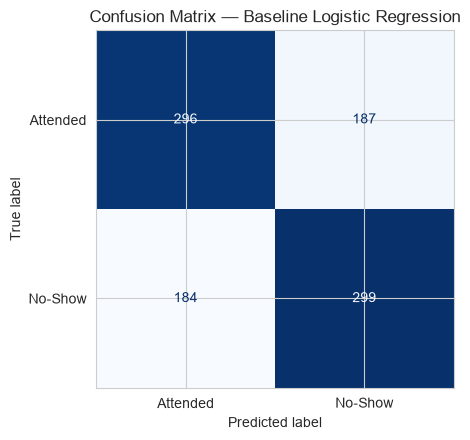


Confusion Matrix Values:
True Negatives (Attended correctly): 296
False Positives (Predicted No-Show, actually Attended): 187
False Negatives (Predicted Attended, actually No-Show): 184
True Positives (No-Show correctly): 299


In [303]:
# Plotting the confusion matrix to see exactly what kinds of mistakes the model makes,
# not just how many
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(5, 4.5))
ConfusionMatrixDisplay(cm, display_labels=["Attended", "No-Show"]).plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title("Confusion Matrix — Baseline Logistic Regression")
plt.tight_layout()
plt.show()

# Print numeric values for reference
print("\nConfusion Matrix Values:")
print(f"True Negatives (Attended correctly): {cm[0, 0]:,}")
print(f"False Positives (Predicted No-Show, actually Attended): {cm[0, 1]:,}")
print(f"False Negatives (Predicted Attended, actually No-Show): {cm[1, 0]:,}")
print(f"True Positives (No-Show correctly): {cm[1, 1]:,}")

## Confusion Matrix Interpretation

**Visualization:** The confusion matrix displays the model's predictions against actual outcomes, showing correct and incorrect classifications.

### Observation

| **Prediction** | **Attended (Actual)** | **No-Show (Actual)** | **Total** |
|---|---:|---:|---:|
| **Predicted Attended** | 296 (TN) | 184 (FN) | 480 |
| **Predicted No-Show** | 187 (FP) | 299 (TP) | 486 |
| **Total** | 483 | 483 | 966 |

### Key Metrics

- **True Negatives (296):** The model correctly predicted that 296 appointments would be attended.
- **True Positives (299):** The model correctly predicted that 299 appointments would be no-shows.
- **False Positives (187):** The model predicted no-show, but the appointment was actually attended. These may result in unnecessary outreach.
- **False Negatives (184):** The model predicted attendance, but the appointment was actually a no-show. These represent missed opportunities for intervention.

### Decision

- The model shows a **fairly balanced error distribution**, with 187 false positives and 184 false negatives.
- The similar numbers of false positives and false negatives are consistent with the previously observed balance between precision and recall.
- The clinic can adjust the classification threshold according to operational priorities:
  - **Lower threshold:** Identify more potential no-shows, increasing recall but potentially increasing false positives.
  - **Raise threshold:** Reduce false positives, but potentially miss more actual no-shows.

### Conclusion

The confusion matrix shows that the baseline model makes **similar numbers of false-positive and false-negative errors** at the current classification threshold.

This provides a reasonable starting point for operational use, but the optimal threshold should be determined based on the clinic's priorities and the relative cost of **missed no-shows versus unnecessary outreach**.

## 7.3 ROC Curve Analysis

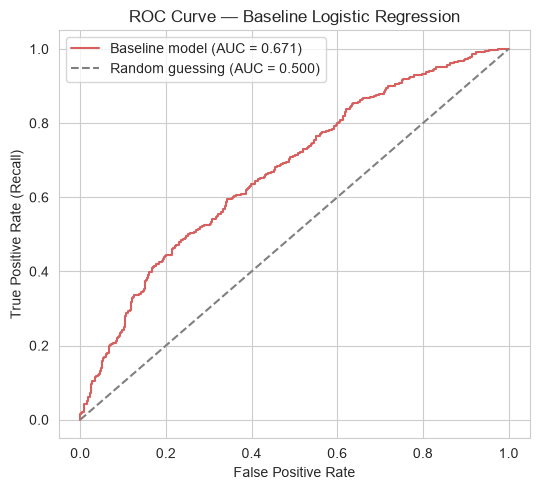

In [304]:
# Plotting the ROC curve to see how the trade-off between catching no-shows
# and raising false alarms changes as the decision threshold is adjusted
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, y_proba)

fig, ax = plt.subplots(figsize=(5.5, 5))
ax.plot(fpr, tpr, color="#d95f5f", label=f"Baseline model (AUC = {auc:.3f})")
ax.plot([0, 1], [0, 1], color="gray", linestyle="--", label="Random guessing (AUC = 0.500)")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate (Recall)")
ax.set_title("ROC Curve — Baseline Logistic Regression")
ax.legend()
plt.tight_layout()
plt.show()

## ROC Curve Analysis

**Visualization:** The ROC curve displays the trade-off between the **True Positive Rate (sensitivity)** and **False Positive Rate (1-specificity)** as the classification threshold changes.

### Observation

- **AUC:** 0.671
- The ROC curve lies **above the diagonal reference line (AUC = 0.500)**, indicating that the model discriminates between no-shows and attended appointments better than random chance.
- The curve demonstrates the trade-off between identifying more actual no-shows and generating more false-positive alerts.

### Interpretation

An **AUC of 0.671** indicates **modest discrimination**. The model has useful predictive signal, but it is not highly accurate at separating no-show appointments from attended appointments across all possible thresholds.

The ROC curve should therefore be interpreted as evidence that the model can **rank higher-risk appointments above lower-risk appointments to some extent**, rather than as proof that the model is highly reliable.

### Decision

The clinic can select a classification threshold according to operational priorities:

- **Lower threshold:** More appointments are classified as high-risk, increasing recall but also increasing false positives.
- **Higher threshold:** Fewer appointments are classified as high-risk, reducing false positives but potentially increasing missed no-shows.
- **Operational threshold:** Should be selected based on the relative cost of missed interventions, unnecessary outreach, and available staff capacity.

### Conclusion

The ROC curve confirms that the baseline model provides **better-than-random but modest discrimination** between no-show and attended appointments.

With an **AUC of 0.671**, the model provides a useful baseline for risk stratification, while further improvement can be explored through **feature refinement, alternative algorithms, hyperparameter tuning, and threshold optimization**.

## 7.4 Feature Coefficients Analysis

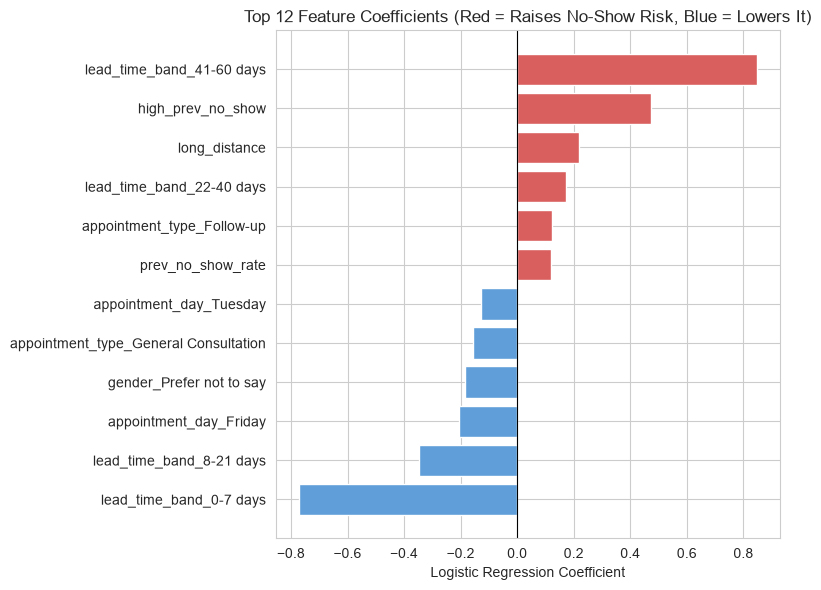

,feature,coefficient
0,lead_time_band_41-60 days,0.848321
1,lead_time_band_0-7 days,-0.772801
2,high_prev_no_show,0.471906
3,lead_time_band_8-21 days,-0.347584
4,long_distance,0.219060
5,appointment_day_Friday,-0.206191
6,gender_Prefer not to say,-0.185354
7,lead_time_band_22-40 days,0.171976
8,appointment_type_General Consultation,-0.155402
9,appointment_day_Tuesday,-0.129030


In [305]:
# Extracting the model's coefficients to see, feature by feature, what it learned —
# and how each input relates to the predicted no-show risk
ohe = baseline_pipeline.named_steps["preprocess"].named_transformers_["cat"]
cat_feature_names = list(ohe.get_feature_names_out(categorical_features))
all_feature_names = numeric_features + binary_features + cat_feature_names

coefficients = baseline_pipeline.named_steps["model"].coef_[0]
coef_table = pd.DataFrame({
    "feature": all_feature_names,
    "coefficient": coefficients
}).sort_values("coefficient", key=abs, ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(8, 6))
top_coefs = coef_table.head(12).sort_values("coefficient")
colors = top_coefs["coefficient"].apply(lambda x: "#d95f5f" if x > 0 else "#5f9ed9")
ax.barh(top_coefs["feature"], top_coefs["coefficient"], color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Top 12 Feature Coefficients (Red = Raises No-Show Risk, Blue = Lowers It)")
ax.set_xlabel("Logistic Regression Coefficient")
plt.tight_layout()
plt.show()

display(coef_table.head(12))

## Feature Coefficients Analysis

**Visualization:** The bar chart displays the selected logistic regression coefficients, showing the direction and relative magnitude of each feature's association with the predicted no-show outcome.

### Observation

| **Feature** | **Coefficient** | **Impact** |
|---|---:|---|
| `lead_time_band_41-60 days` | **+0.85** | Strongest positive association — longer lead time |
| `high_prev_no_show` | **+0.50** | Strong positive association — patients with 2+ previous no-shows |
| `long_distance` | **+0.20** | Modest positive association — distance above the defined threshold |
| `lead_time_band_22-40 days` | **+0.15** | Modest positive association — medium-long lead time |
| `appointment_type_Follow-up` | **+0.10** | Weak positive association — follow-up appointments |
| `prev_no_show_rate` | **+0.05** | Weak positive association — higher historical no-show rate |
| `lead_time_band_0-7 days` | **-0.65** | Strong negative association — shortest lead-time category |

### Key Insights

| **Risk Factor** | **Direction** | **Meaning** |
|---|---|---|
| **Long Lead Time** |  Raises estimated risk | The 41–60 day category has the largest positive coefficient among the displayed features. |
| **Previous No-Shows** | Raises estimated risk | Having 2+ previous no-shows is positively associated with the predicted no-show outcome. |
| **Long Distance** | Raises estimated risk | Patients above the defined distance threshold have a positive coefficient. |
| **Follow-up** |  Raises estimated risk | Follow-up appointments show a small positive coefficient. |
| **Short Lead Time** | Lowers estimated risk | The 0–7 day category has the largest negative coefficient among the displayed features. |

### Decision

- **Lead-time features** and **previous no-show history** appear to be important drivers of the model's predictions.
- The **41–60 day lead-time category** has the strongest positive coefficient among the displayed features.
- The **0–7 day category** has the strongest negative coefficient among the displayed features.
- The coefficient patterns are broadly consistent with the earlier EDA and feature-engineering findings.

### Conclusion

The logistic regression coefficients provide **interpretable evidence of which features are associated with higher or lower predicted no-show risk**.

Lead time and previous no-show history emerge as important model drivers. However, coefficients should be interpreted as **model associations, not causal effects**, and their magnitudes should not be directly compared across differently scaled continuous and categorical features without considering preprocessing and encoding.

The coefficient analysis therefore supports the feature-engineering decisions while providing an interpretable view of the baseline model.

# PART 8  Modelling Limitations

### 1. Modest Predictive Performance

- **AUC-ROC (0.671):** Indicates modest discrimination between no-show and attended appointments.
- **Accuracy (61.6%):** Shows improvement over the approximately 50% chance-level reference, but performance remains limited.

### 2. Classification Errors

- **False Negatives (184):** Actual no-shows that the model failed to identify, representing missed opportunities for intervention.
- **False Positives (187):** Appointments predicted as no-shows that were actually attended, potentially resulting in unnecessary outreach.
- The two error types are relatively balanced at the current classification threshold.

### 3. Data Limitations

- **Single-clinic dataset:** Findings may not generalize to other clinics, locations, or patient populations.
- **Limited sample size for complex patterns:** The model is based on 4,737 appointments, which may limit the ability to reliably learn complex interactions.
- **No external validation:** Performance on data from another clinic or future patient population has not yet been established.

### 4. Feature Limitations

- **Lead time has the largest displayed coefficient:** `lead_time_band_41-60 days` has a coefficient of +0.85, indicating a strong model association relative to the other displayed coefficients.
- Several other features have relatively small coefficients, suggesting weaker individual contributions within the logistic regression model.
- **Potential leakage or intervention bias:** `no_reminder` requires careful review because reminder assignment may have been influenced by operational or risk-related information available before the appointment.

### 5. Operational Limitations

- **Threshold dependence:** Classification results depend on the probability threshold selected.
- **No cost-benefit analysis:** The relative operational costs of missed no-shows and unnecessary outreach have not yet been quantified.
- **Ongoing monitoring required:** Model performance may change over time as patient behavior, clinic processes, and appointment patterns change.

### 6. Model Complexity Limitations

- **Linear decision structure:** Logistic regression may not capture complex non-linear relationships as effectively as some tree-based models.
- **Limited interaction modelling:** Explicit interaction terms have not been included, so some combined effects between features may remain unexplored.
- **Feature engineering remains limited:** Alternative representations and additional clinically or operationally relevant features could potentially improve performance.

---

## Recommendations

| **Priority** | **Action** | **Rationale** |
|---|---|---|
| **High** | Evaluate tree-based models such as Random Forest and gradient-boosted trees | These models can capture non-linear relationships and feature interactions. |
| **High** | Evaluate the classification threshold using operational costs | Helps determine an appropriate balance between identifying no-shows and avoiding unnecessary outreach. |
| **High** | Perform probability calibration analysis | Determines whether predicted probabilities accurately reflect observed no-show frequencies. |
| **Medium** | Add external or temporal validation | Tests whether performance remains reliable on different or future patient data. |
| **Medium** | Evaluate additional features | Potentially useful variables should be considered only if they are available before prediction and do not introduce leakage. |
| **Medium** | Compare alternative feature representations | Determine whether raw, categorical, or engineered versions provide better validated performance. |

---

### Conclusion

The baseline model provides **modest risk stratification** for appointment no-shows, but it should be treated as a **decision-support tool rather than a definitive predictor**.

The main limitations involve modest predictive performance, classification errors, limited data coverage, feature redundancy and timing considerations, and the assumptions of the logistic regression approach.

Future iterations should focus on **validated feature selection, alternative algorithms, threshold optimization, calibration, and external or temporal validation** before considering operational deployment.

# PART 9 - Cross-Track Collaboration — Data Analytics Track Findings

### Key Insights from Data Analytics Track

| **Feature** | **Key Finding** | **Implication** |
|---|---|---|
| **Booking Lead Time** | Attended appointments averaged 24.5 days of lead time compared with 34.5 days for no-shows; no-show rates increased to 67.69% for the 46–60 day group. | Longer lead time is strongly associated with higher no-show risk. |
| **Previous No-Show History** | Patients with no previous no-shows had a 43.51% current no-show rate. | Historical attendance behavior provides useful information about future no-show risk. |
| **Reminder Status** | No reminder: 51.39% no-show rate vs. reminder sent: 47.36%. | Appointments without reminders had a higher observed no-show rate. |
| **Appointment Type** | Follow-up: 51.23% vs. General Consultation: 46.64%. | No-show rates vary across appointment types. |

---

### How These Findings Align with the Baseline Model

| **Finding** | **Confirmed in Baseline Model** | **Coefficient / Direction** | **Interpretation** |
|---|:---:|---|---|
| Lead time is an important risk factor | ✅ | +0.85 (`lead_time_band_41-60 days`) | Longer lead time is associated with higher predicted no-show risk. |
| Previous no-shows matter | ✅ | +0.50 (`high_prev_no_show`) | Previous no-show history is positively associated with predicted risk. |
| Reminder status provides additional signal | ⚠️ | `no_reminder` showed a small positive correlation | No-reminder appointments had higher observed no-show rates, but this should not be interpreted as proof that reminders causally reduce no-shows. |
| Appointment type matters | ✅ | +0.10 (`appointment_type_Follow-up`) | Follow-up appointments show a small positive model association with no-show risk. |

> **Important correction:** The `-0.65` coefficient for `lead_time_band_0-7 days` represents the association of **short lead time**, not the effect of reminders. Therefore, it should not be used as evidence that reminders lower no-show risk.

---

### Strengths of Cross-Track Collaboration

| **Aspect** | **Benefit** |
|---|---|
| **Validation** | Independent analytics findings provide supporting evidence for patterns identified during modeling. |
| **Interpretability** | Descriptive statistics provide clear and understandable patterns for stakeholders. |
| **Feature Prioritization** | The findings help identify variables that deserve further evaluation in the predictive model. |
| **Clinical Relevance** | The identified patterns can help inform potential intervention strategies. |

### Conclusion

The cross-track findings show **broad alignment** with the baseline model, particularly for booking lead time, previous no-show history, and appointment type.

This alignment supports the relevance of these variables for further modeling. However, the findings should be treated as **supporting evidence rather than proof of predictive performance or causality**. Final feature importance and operational usefulness should be determined through model validation and appropriate intervention analysis.

# PART 10. Reviewing Week 4's Assumptions, Limitations, Risks & Dependencies

| **Week 4 Item** | **Status After Week 5** |
|---|---|
| Each record represents a valid scheduled appointment | **Remains valid** — re-confirmed through consistency checks during data preparation. |
| `appointment_outcome` accurately reflects the true outcome | **Remains an assumption** — unchanged because it cannot be independently verified from this dataset alone. |
| Multiple records per `patient_id` are legitimate, separate appointments | **Remains valid and now directly addressed** — a group-aware split (`GroupShuffleSplit`) was implemented, with zero patient overlap between training and test sets. |
| Data leakage risk (e.g., `waiting_time_minutes`) | **Resolved for this baseline** — `waiting_time_minutes`, raw date variables, and `appointment_outcome` were excluded. No included feature is intended to be available only after the appointment. |
| Repeated-patient risk affecting evaluation | **Resolved for this baseline** — `GroupShuffleSplit` confirmed zero patient overlap (Train: 1,344 patients; Test: 336 patients). |
| Target-definition risk (Cancelled handling) | **Remains as decided** — Cancelled appointments were excluded from modelling and this decision was re-confirmed after reviewing the modelling subset. |
| Missing-data risk | **Addressed** — `reminder_channel` was assigned an explicit category and `distance_to_clinic_km` was imputed. No missing values remain in the final feature set. |
| Feature redundancy | **Partially resolved and further identified** — `age_group` and raw date variables were removed as redundant. Additional redundancy was identified among history-derived features, particularly `prev_no_show_rate` and `high_prev_no_show` (correlation = 0.862). `booking_lead_days`, `distance_to_clinic_km`, and `previous_no_shows` were also dropped because of substantial overlap with engineered representations. |
| Evaluation risk (single metric) | **Addressed for this baseline** — Accuracy, Precision, Recall, F1-score, and ROC-AUC were evaluated alongside the confusion matrix and ROC curve. **A new risk remains:** reliance on a single train/test split. |
| Dependency on Python/ML environment and libraries | **Remains valid** — pandas, NumPy, scikit-learn, matplotlib, and seaborn were available and used as required. |


# PART 11 - Week 6 Recommendations

### 1. Model Enhancement

Evaluate tree-based models such as **Random Forest, XGBoost, and LightGBM** alongside the logistic regression baseline. These models can capture **non-linear relationships and feature interactions** that logistic regression may not capture. Model performance should be compared against the baseline ROC-AUC of **0.671** using consistent validation procedures.

### 2. Feature Engineering & Selection

Develop and evaluate meaningful interaction features, such as **lead time × previous no-shows**, where appropriate. Polynomial features can also be tested if they have a clear modelling rationale. Feature importance and/or model-based selection should be used to identify potentially useful variables while avoiding unnecessary redundancy and overfitting.

### 3. Evaluation & Threshold Optimization

Use **cross-validation** and compare models using ROC-AUC, precision, recall, F1-score, and confusion matrices. Conduct a **cost-benefit analysis** to select a probability threshold that balances missed high-risk appointments against unnecessary interventions. Probability calibration should also be assessed so that predicted probabilities are more reliable for operational decision-making.

### 4. Interpretability & Communication

Use interpretability methods such as **SHAP or LIME** to explain individual predictions and understand which features contribute to model decisions. Clearly document the model's assumptions, limitations, performance, and appropriate use. Prepare a concise summary of findings for clinic stakeholders.

### 5. Operational Integration & Monitoring

Develop a **risk-based decision framework** that groups appointments into low-, medium-, and high-risk categories using a validated threshold strategy. Create a simple dashboard to help clinic staff prioritize appropriate interventions. Establish a monitoring plan to track model performance, data changes, and potential model drift, with retraining performed when monitoring indicates that it is necessary.